In [ ]:

# Univariate Miami Code: 




# ============================================================
# 1. Imports and Global Configuration
# ============================================================

import sys
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Prophet
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [2]:
import sys
print(sys.executable)

c:\Users\ajha26\Python310\python.exe


In [3]:
import sys
!{sys.executable} -m pip install tensorflow

   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   - -------------------------------------- 13.1/350.6 MB 81.8 MB/s eta 0:00:05
   ---- ---------------------------------- 38.0/350.6 MB 100.7 MB/s eta 0:00:04
   ------- ------------------------------- 63.7/350.6 MB 106.8 MB/s eta 0:00:03
   --------- ----------------------------- 89.4/350.6 MB 109.6 MB/s eta 0:00:03
   ------------ ------------------------- 114.6/350.6 MB 110.8 MB/s eta 0:00:03
   --------------- ---------------------- 139.2/350.6 MB 111.1 MB/s eta 0:00:02
   ---------------- --------------------- 154.9/350.6 MB 105.3 MB/s eta 0:00:02
   ------------------- ------------------ 180.6/350.6 MB 107.9 MB/s eta 0:00:02
   --------------------- ---------------- 202.9/350.6 MB 107.2 MB/s eta 0:00:02
   ------------------------ ------------- 228.6/350.6 MB 108.2 MB/s eta 0:00:02
   --------------------------- ---------- 254.3/350.6 MB 109.1 MB/s eta 0:00:01
   ------------------------------ ------- 280.0/3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ============================================================
# 2. Data Loading
# ============================================================

univariate_city_path = r"C:\Users\ajha26\Desktop\Research\Code\Statistical Time Series\Miami_and_Hialeah_alltraps.xlsx"

df_city = pd.read_excel(univariate_city_path)

df_city["Date_Submitted"] = pd.to_datetime(df_city["Date_Submitted"])
df_city = df_city.sort_values("Date_Submitted").reset_index(drop=True)

df_city.head()

,Date_Submitted,Cx_quinquefasciatus_fem,TRAPID,City
0,2016-01-05,2,E5,Miami
1,2016-01-05,3,E1,Miami
2,2016-01-12,2,KB1,Miami
3,2016-01-12,1,E2,Miami
4,2016-01-12,6,VK1,Miami


In [6]:
# ============================================================
# 3. Miami Weekly Time Series
# ============================================================

df_miami = df_city[df_city["City"] == "Miami"].copy()

def weekly_aggregate(df, date_col, value_col):
    """
    Aggregates mosquito counts to weekly frequency.
    Missing weeks are filled with zero because no recorded mosquitoes
    should represent zero observed count for that week.
    """
    ts = (
        df.set_index(date_col)
        .resample("W")[value_col]
        .sum()
        .to_frame(name="mosquito_count")
    )
    
    ts["mosquito_count"] = ts["mosquito_count"].fillna(0)
    return ts

ts_miami = weekly_aggregate(
    df_miami,
    date_col="Date_Submitted",
    value_col="Cx_quinquefasciatus_fem"
)

print("Miami weekly series shape:", ts_miami.shape)
ts_miami.head()

Miami weekly series shape: (309, 1)


,mosquito_count
Date_Submitted,
2016-01-10,5
2016-01-17,9
2016-01-24,5
2016-01-31,11
2016-02-07,0


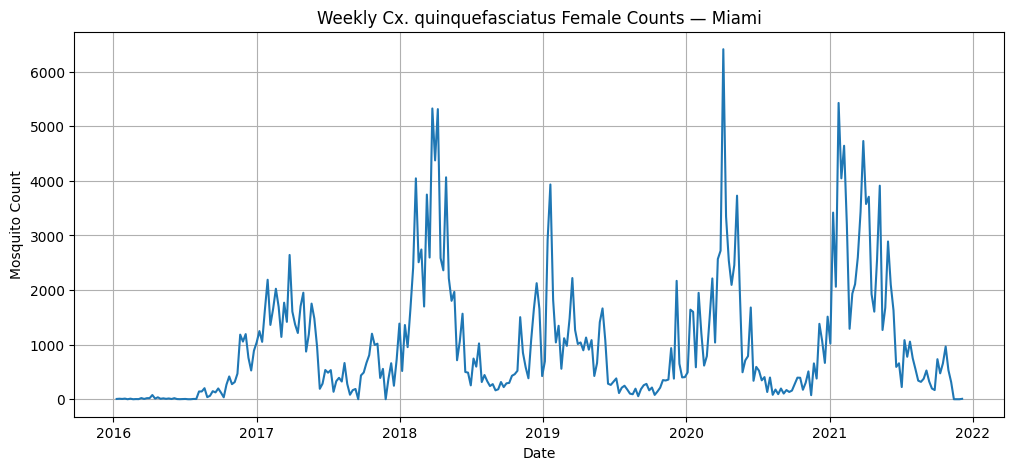

In [7]:
# ============================================================
# 4. Exploratory Visualization
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(ts_miami.index, ts_miami["mosquito_count"])
plt.title("Weekly Cx. quinquefasciatus Female Counts — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.show()

In [8]:
# ============================================================
# 5. Evaluation Framework
# ============================================================

ts_series = ts_miami["mosquito_count"]

train_size = int(len(ts_series) * 0.8)

train_series = ts_series.iloc[:train_size]
test_series = ts_series.iloc[train_size:]

print("Train size:", len(train_series))
print("Test size:", len(test_series))
print("Train period:", train_series.index.min(), "to", train_series.index.max())
print("Test period:", test_series.index.min(), "to", test_series.index.max())


def compute_metrics(y_true, y_pred):
    """
    Computes forecast evaluation metrics.

    MAPE is calculated safely by ignoring points where y_true = 0.
    SMAPE is added because mosquito counts may contain zeros.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    # Zero-safe MAPE
    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    # SMAPE handles zeros better than MAPE
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0
    if np.sum(smape_mask) > 0:
        smape = np.mean(np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denominator[smape_mask]) * 100
    else:
        smape = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": nrmse,
        "MAPE": mape,
        "SMAPE": smape
    }


model_results = []

def add_result(model_name, y_true, y_pred):
    metrics = compute_metrics(y_true, y_pred)
    model_results.append({
        "City": "Miami",
        "Model": model_name,
        **metrics
    })
    return metrics

Train size: 247
Test size: 62
Train period: 2016-01-10 00:00:00 to 2020-09-27 00:00:00
Test period: 2020-10-04 00:00:00 to 2021-12-05 00:00:00


In [9]:
# ============================================================
# 6. Baseline Models
# Research Question:
# How much forecasting skill can be achieved using only simple
# temporal persistence and smoothing rules?
# ============================================================

def naive_forecast(train):
    return train.iloc[-1]

def seasonal_naive_forecast(train, season_length=52):
    if len(train) < season_length:
        return train.iloc[-1]
    return train.iloc[-season_length]

def rolling_mean_forecast(train, window=4):
    return train.iloc[-window:].mean()


def evaluate_expanding_baseline(ts, model_fn, initial_train_size, **kwargs):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        pred = model_fn(train, **kwargs)

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


INITIAL_TRAIN_SIZE = 52

baseline_specs = [
    ("Naive", naive_forecast, {}),
    ("Seasonal Naive", seasonal_naive_forecast, {"season_length": 52}),
    ("Rolling Mean", rolling_mean_forecast, {"window": 4})
]

for name, fn, kwargs in baseline_specs:
    y_true, y_pred = evaluate_expanding_baseline(
        ts_series,
        fn,
        initial_train_size=INITIAL_TRAIN_SIZE,
        **kwargs
    )
    
    metrics = add_result(name, y_true, y_pred)
    print(name, metrics)

baseline_df = pd.DataFrame(model_results)
baseline_df

Naive {'RMSE': 828.6870070430833, 'MAE': 547.1050583657587, 'R2': 0.48826438771763614, 'nRMSE': 0.7095561231590725, 'MAPE': 63.13459182859149, 'SMAPE': 52.73989471551476}
Seasonal Naive {'RMSE': 1235.002567775651, 'MAE': 834.3151750972762, 'R2': -0.1365807677371007, 'nRMSE': 1.0574603277650179, 'MAPE': 161.74669685580665, 'SMAPE': 87.40355711922336}
Rolling Mean {'RMSE': 834.8131706630242, 'MAE': 551.2577821011673, 'R2': 0.48067029272357775, 'nRMSE': 0.7148015980742806, 'MAPE': 71.25950031612497, 'SMAPE': 52.73525456050986}


,City,Model,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Miami,Naive,828.687007,547.105058,0.488264,0.709556,63.134592,52.739895
1,Miami,Seasonal Naive,1235.002568,834.315175,-0.136581,1.057460,161.746697,87.403557
2,Miami,Rolling Mean,834.813171,551.257782,0.480670,0.714802,71.259500,52.735255


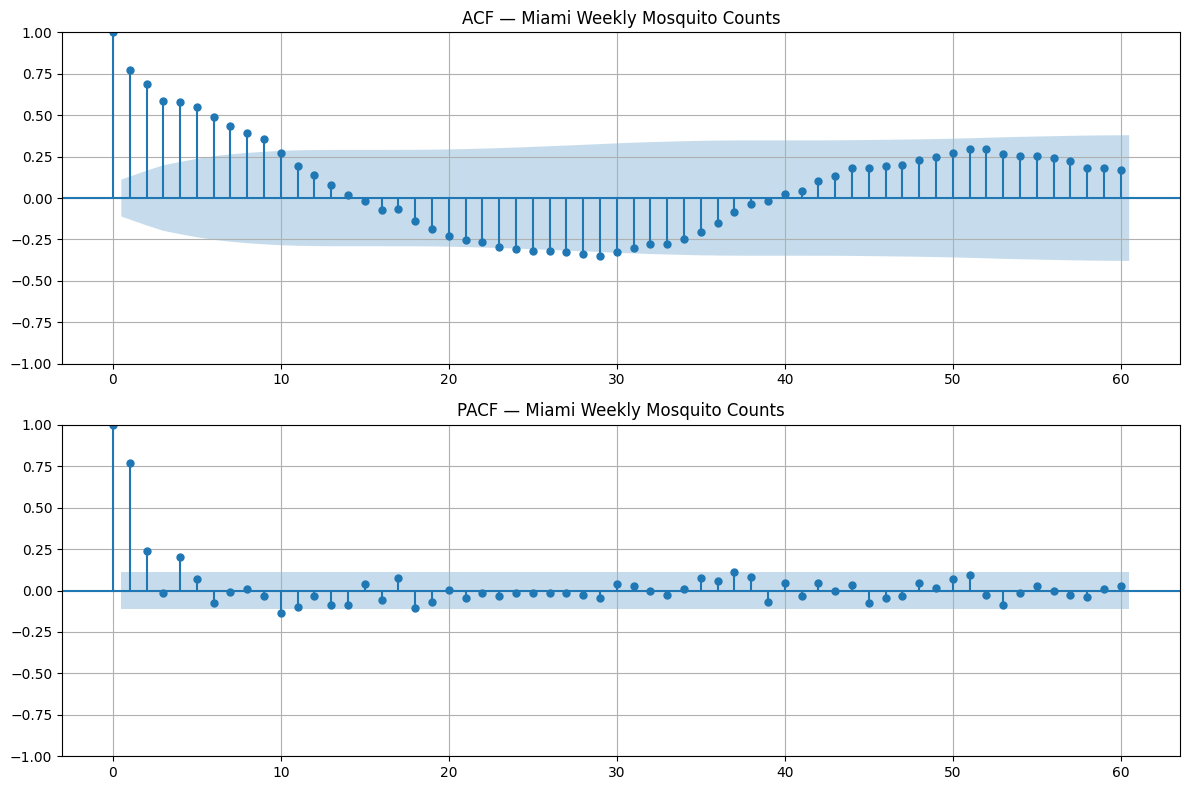

In [10]:
# ============================================================
# 7. Autocorrelation Analysis
# Research Question:
# Do mosquito counts show short-term persistence or seasonal memory?
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts_series, lags=60, ax=axes[0])
axes[0].set_title("ACF — Miami Weekly Mosquito Counts")

plot_pacf(ts_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Miami Weekly Mosquito Counts")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 8. Stationarity Tests
# ============================================================

def stationarity_tests(ts):
    """
    Runs ADF and KPSS tests.
    ADF null hypothesis: series is non-stationary.
    KPSS null hypothesis: series is stationary.
    """
    ts_clean = ts.dropna()

    adf_result = adfuller(ts_clean, autolag="AIC")
    kpss_result = kpss(ts_clean, regression="c", nlags="auto")

    return pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]]
    })

stationarity_tests(ts_series)

,Test,Statistic,p-value
0,ADF,-3.497794,0.008044
1,KPSS,0.259826,0.100000


In [12]:
# ============================================================
# 9. Residual Diagnostic Function
# ============================================================

def residual_diagnostics(residuals, fitted_values=None, title="Residual Diagnostics"):
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals Over Time")

    if fitted_values is not None:
        fitted_values = np.array(fitted_values)
        min_len = min(len(fitted_values), len(residuals))
        axes[0, 1].scatter(fitted_values[-min_len:], residuals[-min_len:])
        axes[0, 1].axhline(0, linestyle="--")
        axes[0, 1].set_title("Residuals vs Fitted")
    else:
        axes[0, 1].hist(residuals, bins=25)
        axes[0, 1].set_title("Residual Distribution")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF of Residuals")

    qqplot(residuals, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Ljung-Box Test:")
    display(acorr_ljungbox(residuals, lags=[10, 20], return_df=True))

In [16]:
# ============================================================
# 10. ARIMA Hyperparameter Tuning
# Research Question:
# Can tuned ARIMA models outperform simple temporal baselines?
# ============================================================

def tune_arima(train, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                try:
                    model = ARIMA(train, order=order)
                    fitted = model.fit()

                    results.append({
                        "order": order,
                        "AIC": fitted.aic,
                        "BIC": fitted.bic
                    })

                except Exception as e:
                    continue

    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


arima_tuning_results = tune_arima(
    train_series,
    p_values=range(0, 5),
    d_values=range(0, 1),
    q_values=range(0, 5)
)

arima_tuning_results.head(10)

,order,AIC,BIC
0,"(3, 0, 4)",3894.241679,3925.826174
1,"(4, 0, 4)",3894.401330,3929.495213
2,"(2, 0, 4)",3894.453437,3922.528544
3,"(4, 0, 2)",3895.903881,3923.978988
4,"(4, 0, 0)",3897.437765,3918.494095
5,"(4, 0, 3)",3897.608363,3929.192858
6,"(1, 0, 4)",3897.947820,3922.513538
7,"(4, 0, 1)",3898.838498,3923.404217
8,"(3, 0, 3)",3899.830919,3927.906026
9,"(2, 0, 3)",3905.951644,3930.517363


Best ARIMA order: (3, 0, 4)
{'RMSE': 1471.4240861620717, 'MAE': 993.3272546926189, 'R2': -0.16638338654925233, 'nRMSE': 1.058983984840429, 'MAPE': 303.0084911303563, 'SMAPE': 79.62581699875375}


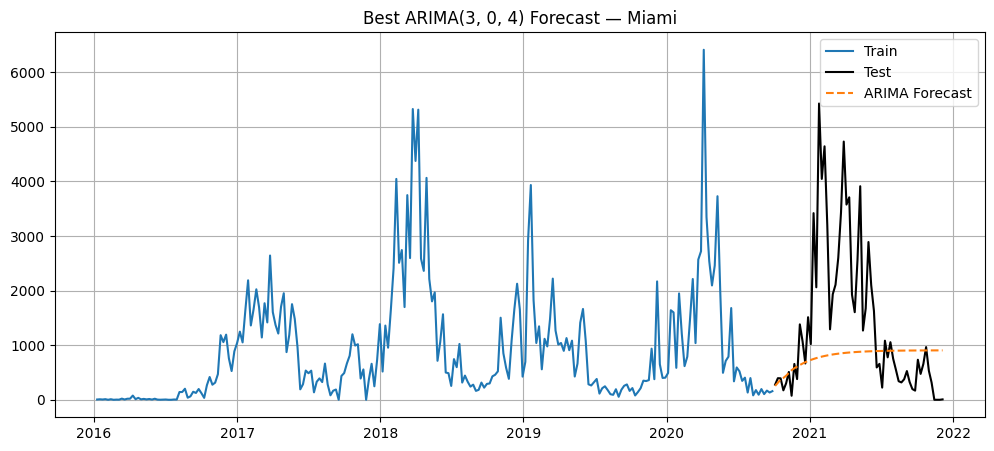

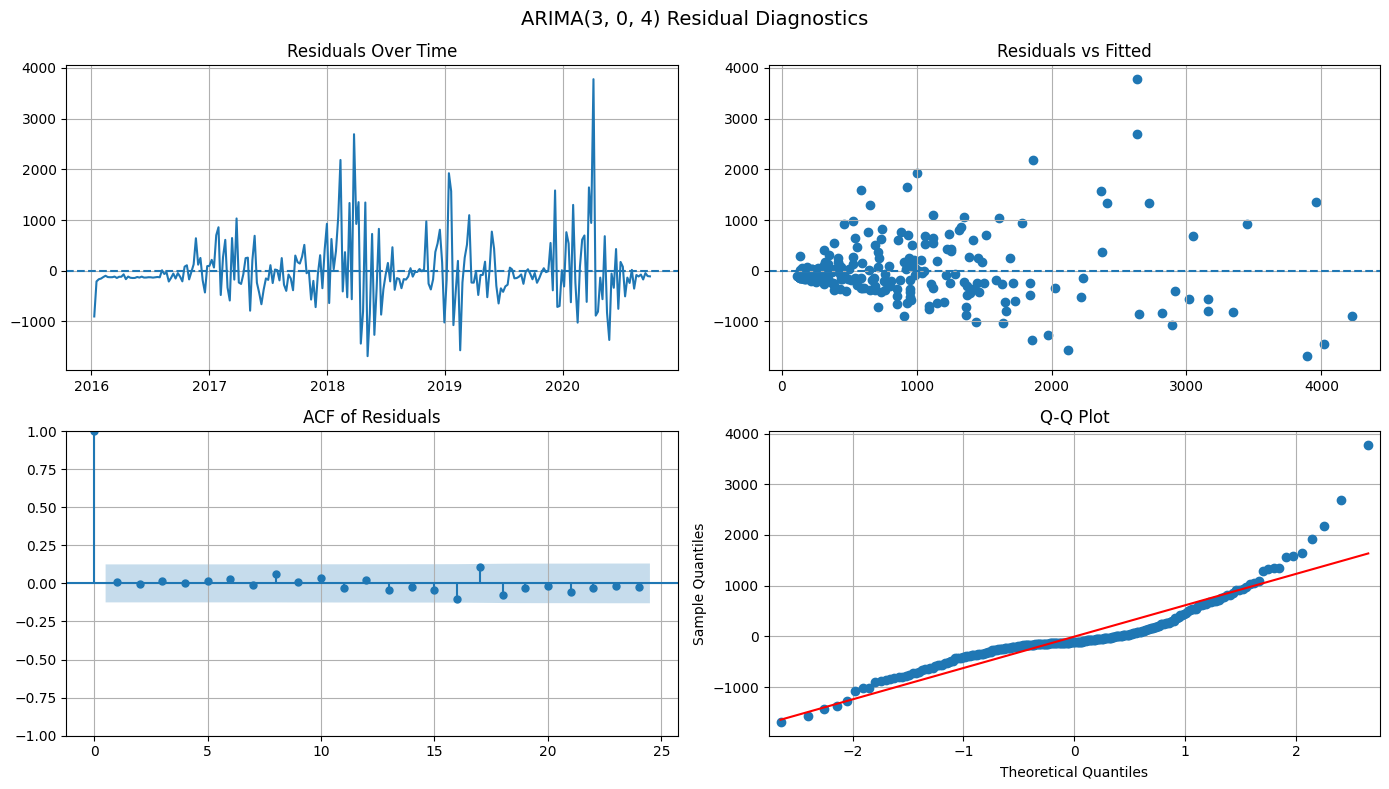

Ljung-Box Test:


,lb_stat,lb_pvalue
10,1.596479,0.998602
20,11.136109,0.942616


In [17]:
# ============================================================
# 11. Best ARIMA Evaluation
# ============================================================

best_arima_order = arima_tuning_results.iloc[0]["order"]
print("Best ARIMA order:", best_arima_order)

best_arima = ARIMA(train_series, order=best_arima_order).fit()

arima_forecast = best_arima.forecast(steps=len(test_series))
arima_forecast.index = test_series.index

metrics = add_result(f"ARIMA{best_arima_order}", test_series, arima_forecast)
print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.title(f"Best ARIMA{best_arima_order} Forecast — Miami")
plt.legend()
plt.show()

residual_diagnostics(
    best_arima.resid,
    fitted_values=best_arima.fittedvalues,
    title=f"ARIMA{best_arima_order} Residual Diagnostics"
)

In [ ]:
# ============================================================
# 13. Best SARIMA Evaluation
# ============================================================

best_sarima_order = sarima_tuning_results.iloc[0]["order"]
best_sarima_seasonal_order = sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best SARIMA order:", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

best_sarima = SARIMAX(
    train_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = best_sarima.forecast(steps=len(test_series))
sarima_forecast.index = test_series.index

metrics = add_result(
    f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    test_series,
    sarima_forecast
)

print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast", linestyle="--")
plt.title("Best SARIMA Forecast — Miami")
plt.legend()
plt.show()

residual_diagnostics(
    best_sarima.resid,
    fitted_values=best_sarima.fittedvalues,
    title="Best SARIMA Residual Diagnostics"
)

In [18]:
# ============================================================
# 14. Log-Transformed ARIMA
# Research Question:
# Does stabilizing variance improve model performance when residuals
# show a megaphone pattern?
#
# We use log1p because mosquito counts may include zeros.
# log1p(y) = log(1 + y)
# inverse = expm1(y)
# ============================================================

log_train = np.log1p(train_series)
log_test = np.log1p(test_series)

log_arima_tuning_results = tune_arima(
    log_train,
    p_values=range(0, 5),
    d_values=range(0, 1),
    q_values=range(0, 5)
)

log_arima_tuning_results.head(10)

,order,AIC,BIC
0,"(2, 0, 2)",680.845323,701.901653
1,"(4, 0, 1)",681.998837,706.564556
2,"(4, 0, 4)",682.348947,717.442830
3,"(2, 0, 3)",682.636923,707.202642
4,"(3, 0, 2)",682.678759,707.244477
5,"(1, 0, 1)",682.894256,696.931809
6,"(4, 0, 2)",683.952798,712.027905
7,"(2, 0, 4)",683.992693,712.067799
8,"(2, 0, 1)",684.016152,701.563093
9,"(1, 0, 2)",684.163643,701.710584


Best log-ARIMA order: (2, 0, 2)
{'RMSE': 1819.1288667437016, 'MAE': 1232.784074793547, 'R2': -0.7827585763436486, 'nRMSE': 1.3092271319733653, 'MAPE': 120.85633588657849, 'SMAPE': 126.23177772125709}


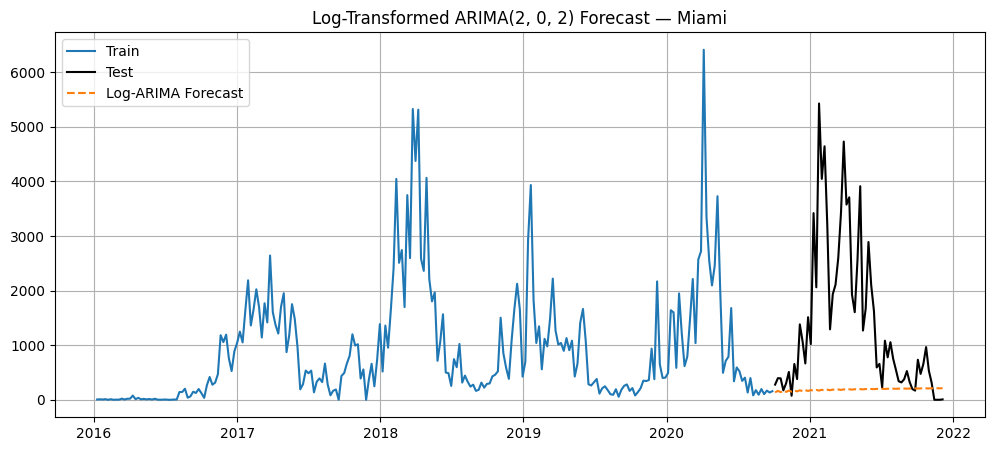

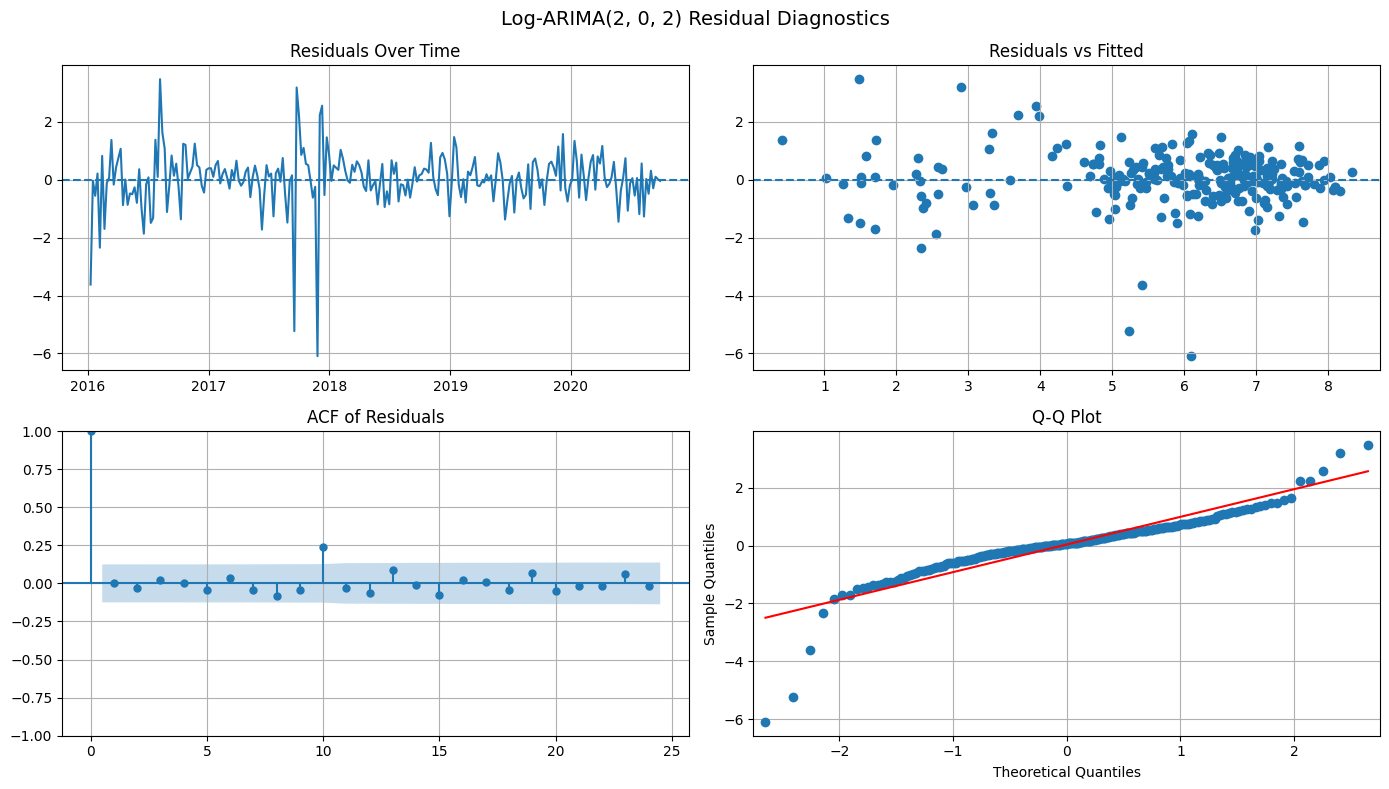

Ljung-Box Test:


,lb_stat,lb_pvalue
10,18.428676,0.048149
20,25.775249,0.173364


In [19]:
best_log_arima_order = log_arima_tuning_results.iloc[0]["order"]
print("Best log-ARIMA order:", best_log_arima_order)

best_log_arima = ARIMA(log_train, order=best_log_arima_order).fit()

log_forecast = best_log_arima.forecast(steps=len(test_series))
log_forecast.index = test_series.index

# Convert forecast back to original mosquito-count scale
log_arima_forecast_original_scale = np.expm1(log_forecast)
log_arima_forecast_original_scale = np.maximum(log_arima_forecast_original_scale, 0)

metrics = add_result(
    f"Log-ARIMA{best_log_arima_order}",
    test_series,
    log_arima_forecast_original_scale
)

print(metrics)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_arima_forecast_original_scale.index,
    log_arima_forecast_original_scale,
    label="Log-ARIMA Forecast",
    linestyle="--"
)
plt.title(f"Log-Transformed ARIMA{best_log_arima_order} Forecast — Miami")
plt.legend()
plt.show()

residual_diagnostics(
    best_log_arima.resid,
    fitted_values=best_log_arima.fittedvalues,
    title=f"Log-ARIMA{best_log_arima_order} Residual Diagnostics"
)

In [20]:
def rolling_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            pred = fitted.forecast(steps=1).iloc[0]
        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)


y_true_roll_arima, y_pred_roll_arima = rolling_arima_forecast(
    ts_series,
    order=(3, 0, 4),
    initial_train_size=52
)

metrics_roll_arima = compute_metrics(y_true_roll_arima, y_pred_roll_arima)
print(metrics_roll_arima)

{'RMSE': 794.7984148937577, 'MAE': 526.0804556425422, 'R2': 0.5292627493807084, 'nRMSE': 0.6805393075695596, 'MAPE': 77.00064788803121, 'SMAPE': 52.65462231442901}


In [21]:
sqrt_train = np.sqrt(train_series)

sqrt_arima_tuning_results = tune_arima(
    sqrt_train,
    p_values=range(0, 5),
    d_values=[0, 1],
    q_values=range(0, 5)
)

best_sqrt_order = sqrt_arima_tuning_results.iloc[0]["order"]
print("Best sqrt-ARIMA order:", best_sqrt_order)

sqrt_arima = ARIMA(sqrt_train, order=best_sqrt_order).fit()

sqrt_forecast = sqrt_arima.forecast(steps=len(test_series))
sqrt_forecast.index = test_series.index

sqrt_forecast_original = np.square(sqrt_forecast)
sqrt_forecast_original = np.maximum(sqrt_forecast_original, 0)

metrics_sqrt_arima = compute_metrics(test_series, sqrt_forecast_original)
print(metrics_sqrt_arima)

Best sqrt-ARIMA order: (3, 1, 2)
{'RMSE': 1841.7876233036507, 'MAE': 1260.95616336338, 'R2': -0.8274466361017425, 'nRMSE': 1.3255346401479604, 'MAPE': 110.60628786403603, 'SMAPE': 135.86954012031717}


In [23]:
threshold = np.percentile(y_true_roll_arima, 90)
mask = y_true_roll_arima >= threshold

peak_rmse = np.sqrt(mean_squared_error(
    y_true_roll_arima[mask],
    y_pred_roll_arima[mask]
))

print("Peak RMSE:", peak_rmse)

Peak RMSE: 1721.676961153118


In [24]:
arima_results = []

In [25]:
def add_arima_result(model_name, order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)

    if fitted_model is not None:
        aic = fitted_model.aic
        bic = fitted_model.bic
    else:
        aic = np.nan
        bic = np.nan

    arima_results.append({
        "Model": model_name,
        "Order": str(order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": aic,
        "BIC": bic
    })

In [29]:
# Fixed Arima


add_arima_result(
    model_name="ARIMA (One-shot)",
    order=best_arima_order,
    y_true=test_series,
    y_pred=arima_forecast,
    fitted_model=best_arima
)

In [30]:
# Rolling ARIMA

add_arima_result(
    model_name="ARIMA (Rolling)",
    order=best_arima_order,
    y_true=y_true_roll_arima,
    y_pred=y_pred_roll_arima,
    fitted_model=None  # no single AIC/BIC
)

In [33]:
# Log ARIMA 

add_arima_result(
    model_name="Log-ARIMA",
    order=best_log_arima_order,
    y_true=test_series,
    y_pred=log_arima_forecast_original_scale,
    fitted_model=best_log_arima
)

In [34]:
# SQRT ARIMA

add_arima_result(
    model_name="Sqrt-ARIMA",
    order=best_sqrt_order,
    y_true=test_series,
    y_pred=sqrt_forecast_original,
    fitted_model=sqrt_arima
)

In [35]:
arima_results_df = pd.DataFrame(arima_results)

# Sort by RMSE (best first)
arima_results_df = arima_results_df.sort_values("RMSE").reset_index(drop=True)

arima_results_df

,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ARIMA (Rolling),"(3, 0, 4)",794.798415,526.080456,0.529263,0.680539,77.000648,52.654622,NaN,NaN
1,ARIMA (Rolling),"(3, 0, 4)",794.798415,526.080456,0.529263,0.680539,77.000648,52.654622,NaN,NaN
2,ARIMA (One-shot),"(3, 0, 4)",1471.424086,993.327255,-0.166383,1.058984,303.008491,79.625817,3894.241679,3925.826174
3,ARIMA (One-shot),"(3, 0, 4)",1471.424086,993.327255,-0.166383,1.058984,303.008491,79.625817,3894.241679,3925.826174
4,ARIMA (One-shot),"(3, 0, 4)",1471.424086,993.327255,-0.166383,1.058984,303.008491,79.625817,3894.241679,3925.826174
5,Log-ARIMA,"(2, 0, 2)",1819.128867,1232.784075,-0.782759,1.309227,120.856336,126.231778,680.845323,701.901653
6,Sqrt-ARIMA,"(3, 1, 2)",1841.787623,1260.956163,-0.827447,1.325535,110.606288,135.869540,1747.941518,1768.973508


In [38]:
arima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})


,Model,Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ARIMA (Rolling),"(3, 0, 4)",794.80,526.08,0.529,0.681,77.00,52.65,nan,nan
1,ARIMA (Rolling),"(3, 0, 4)",794.80,526.08,0.529,0.681,77.00,52.65,nan,nan
2,ARIMA (One-shot),"(3, 0, 4)",1471.42,993.33,-0.166,1.059,303.01,79.63,3894.24,3925.83
3,ARIMA (One-shot),"(3, 0, 4)",1471.42,993.33,-0.166,1.059,303.01,79.63,3894.24,3925.83
4,ARIMA (One-shot),"(3, 0, 4)",1471.42,993.33,-0.166,1.059,303.01,79.63,3894.24,3925.83
5,Log-ARIMA,"(2, 0, 2)",1819.13,1232.78,-0.783,1.309,120.86,126.23,680.85,701.90
6,Sqrt-ARIMA,"(3, 1, 2)",1841.79,1260.96,-0.827,1.326,110.61,135.87,1747.94,1768.97


In [39]:
# ============================================================
# Rolling ARIMA Forecast Plot and Diagnostics
# ============================================================

# Convert rolling results into Series with correct date index
rolling_start_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_arima_true = pd.Series(
    y_true_roll_arima,
    index=rolling_start_index,
    name="True"
)

rolling_arima_pred = pd.Series(
    y_pred_roll_arima,
    index=rolling_start_index,
    name="Rolling ARIMA Forecast"
)

rolling_arima_residuals = rolling_arima_true - rolling_arima_pred

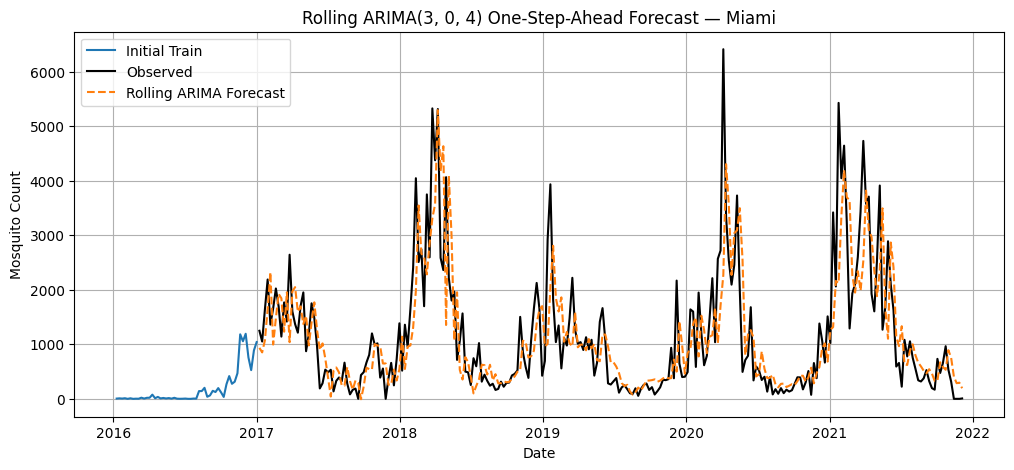

In [40]:
# ============================================================
# Forecast Plot: Rolling ARIMA
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    ts_series.index[:INITIAL_TRAIN_SIZE],
    ts_series.iloc[:INITIAL_TRAIN_SIZE],
    label="Initial Train"
)

plt.plot(
    rolling_arima_true.index,
    rolling_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_arima_pred.index,
    rolling_arima_pred,
    label="Rolling ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling ARIMA{best_arima_order} One-Step-Ahead Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

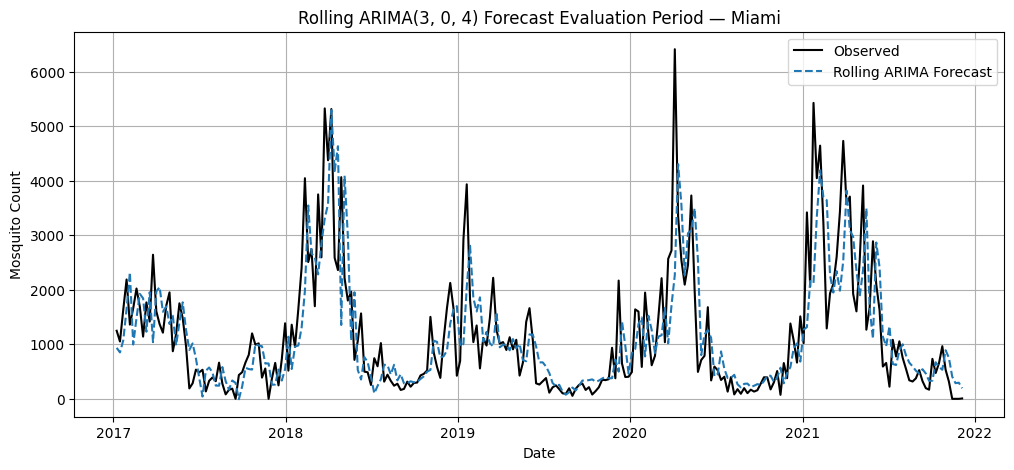

In [41]:
# ============================================================
# Zoomed Forecast Plot: Rolling ARIMA Evaluation Period Only
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_arima_true.index,
    rolling_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_arima_pred.index,
    rolling_arima_pred,
    label="Rolling ARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling ARIMA{best_arima_order} Forecast Evaluation Period — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

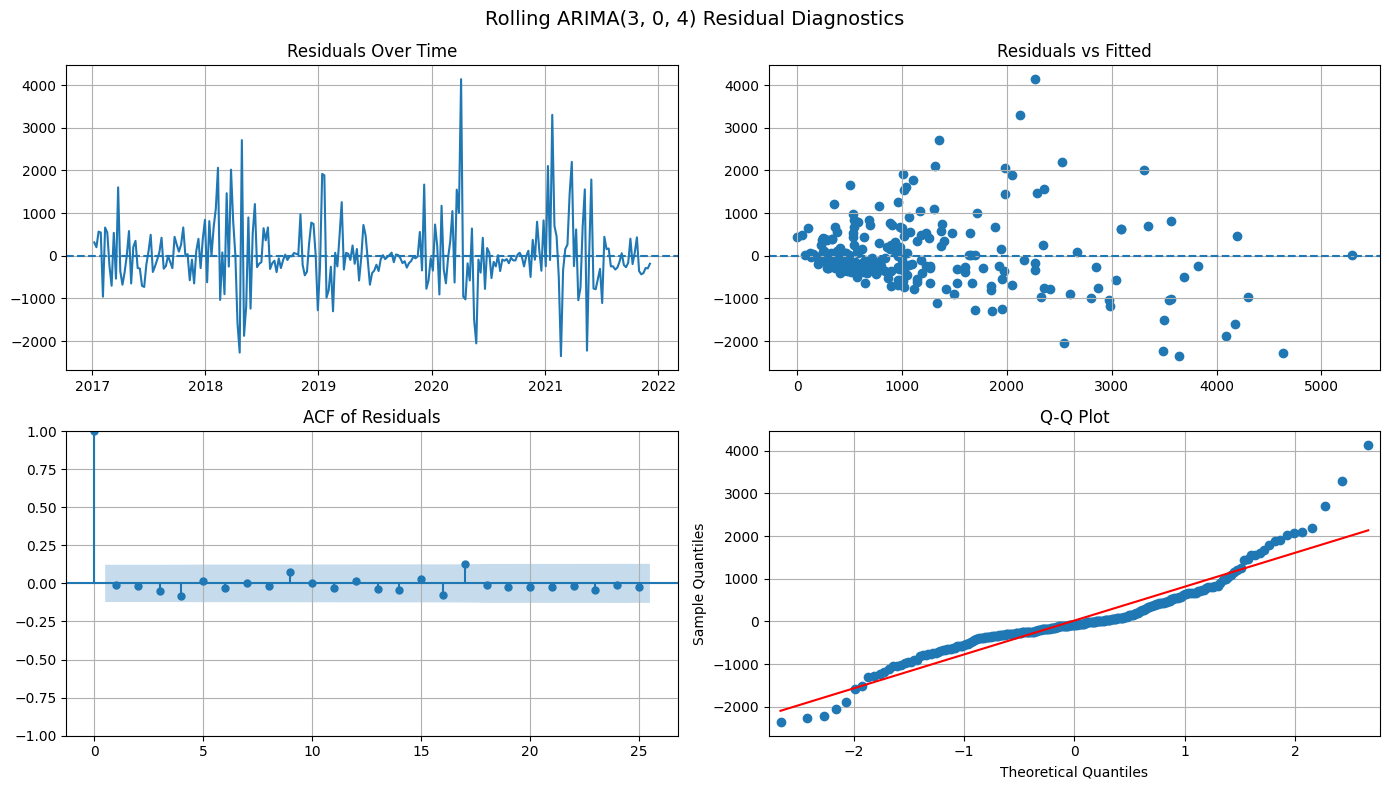

Ljung-Box Test:


,lb_stat,lb_pvalue
10,4.338234,0.930801
20,12.489490,0.898199


In [42]:
# ============================================================
# Rolling ARIMA Residual Diagnostics
# ============================================================

residual_diagnostics(
    rolling_arima_residuals,
    fitted_values=rolling_arima_pred,
    title=f"Rolling ARIMA{best_arima_order} Residual Diagnostics"
)

In [43]:
# ============================================================
# Ljung-Box Test for Rolling ARIMA Residuals
# ============================================================

acorr_ljungbox(
    rolling_arima_residuals.dropna(),
    lags=[10, 20, 30],
    return_df=True
)

,lb_stat,lb_pvalue
10,4.338234,0.930801
20,12.489490,0.898199
30,17.059600,0.971853


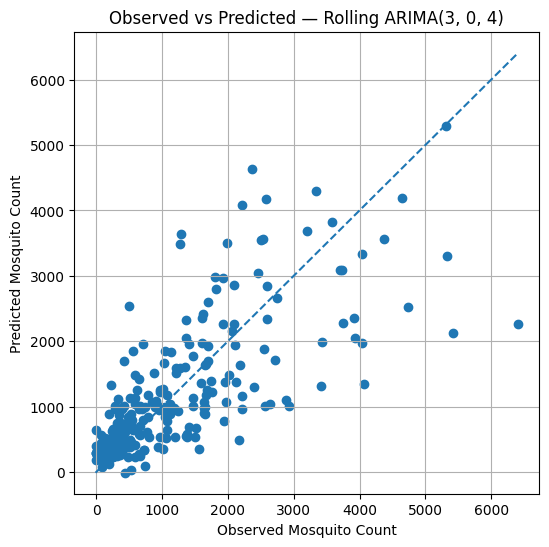

In [44]:
# ============================================================
# Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(rolling_arima_true, rolling_arima_pred)

min_val = min(rolling_arima_true.min(), rolling_arima_pred.min())
max_val = max(rolling_arima_true.max(), rolling_arima_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Observed vs Predicted — Rolling ARIMA{best_arima_order}")
plt.xlabel("Observed Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.show()

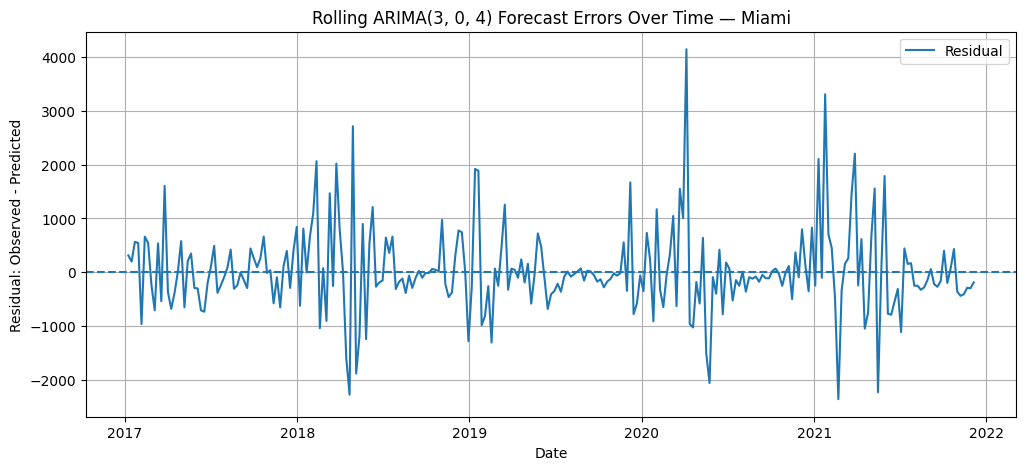

In [45]:
# ============================================================
# Rolling ARIMA Error Over Time
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_arima_residuals.index,
    rolling_arima_residuals,
    label="Residual"
)

plt.axhline(0, linestyle="--")

plt.title(f"Rolling ARIMA{best_arima_order} Forecast Errors Over Time — Miami")
plt.xlabel("Date")
plt.ylabel("Residual: Observed - Predicted")
plt.legend()
plt.show()

In [46]:
# ============================================================
# Rolling Log-ARIMA(3,0,4)
# ============================================================

def rolling_log_arima_forecast(ts, order, initial_train_size):
    y_true, y_pred = [], []

    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]

        # log transform training data
        log_train = np.log1p(train)

        try:
            model = ARIMA(log_train, order=order)
            fitted = model.fit()

            # forecast on log scale
            log_pred = fitted.forecast(steps=1).iloc[0]

            # convert back to original scale
            pred = np.expm1(log_pred)

            # avoid negative predictions
            pred = max(pred, 0)

        except Exception:
            pred = train.iloc[-1]

        y_true.append(test_value)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)

In [47]:
# Run rolling log-ARIMA using the same best raw ARIMA order
y_true_roll_log_arima, y_pred_roll_log_arima = rolling_log_arima_forecast(
    ts_series,
    order=(3, 0, 4),
    initial_train_size=INITIAL_TRAIN_SIZE
)

metrics_roll_log_arima = compute_metrics(
    y_true_roll_log_arima,
    y_pred_roll_log_arima
)

print(metrics_roll_log_arima)

{'RMSE': 822.0799334931843, 'MAE': 516.1992283143804, 'R2': 0.4963919346511847, 'nRMSE': 0.7038988732521128, 'MAPE': 55.3897214999441, 'SMAPE': 53.757066895957685}


In [48]:
add_arima_result(
    model_name="Rolling Log-ARIMA",
    order=(3, 0, 4),
    y_true=y_true_roll_log_arima,
    y_pred=y_pred_roll_log_arima,
    fitted_model=None
)

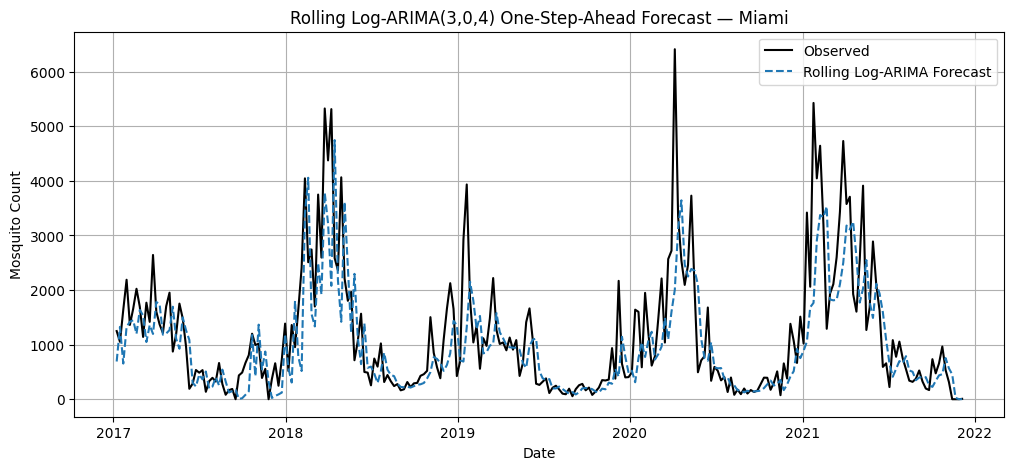

In [49]:
rolling_log_arima_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_log_arima_true = pd.Series(
    y_true_roll_log_arima,
    index=rolling_log_arima_index,
    name="True"
)

rolling_log_arima_pred = pd.Series(
    y_pred_roll_log_arima,
    index=rolling_log_arima_index,
    name="Rolling Log-ARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_arima_true.index,
    rolling_log_arima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_arima_pred.index,
    rolling_log_arima_pred,
    label="Rolling Log-ARIMA Forecast",
    linestyle="--"
)

plt.title("Rolling Log-ARIMA(3,0,4) One-Step-Ahead Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

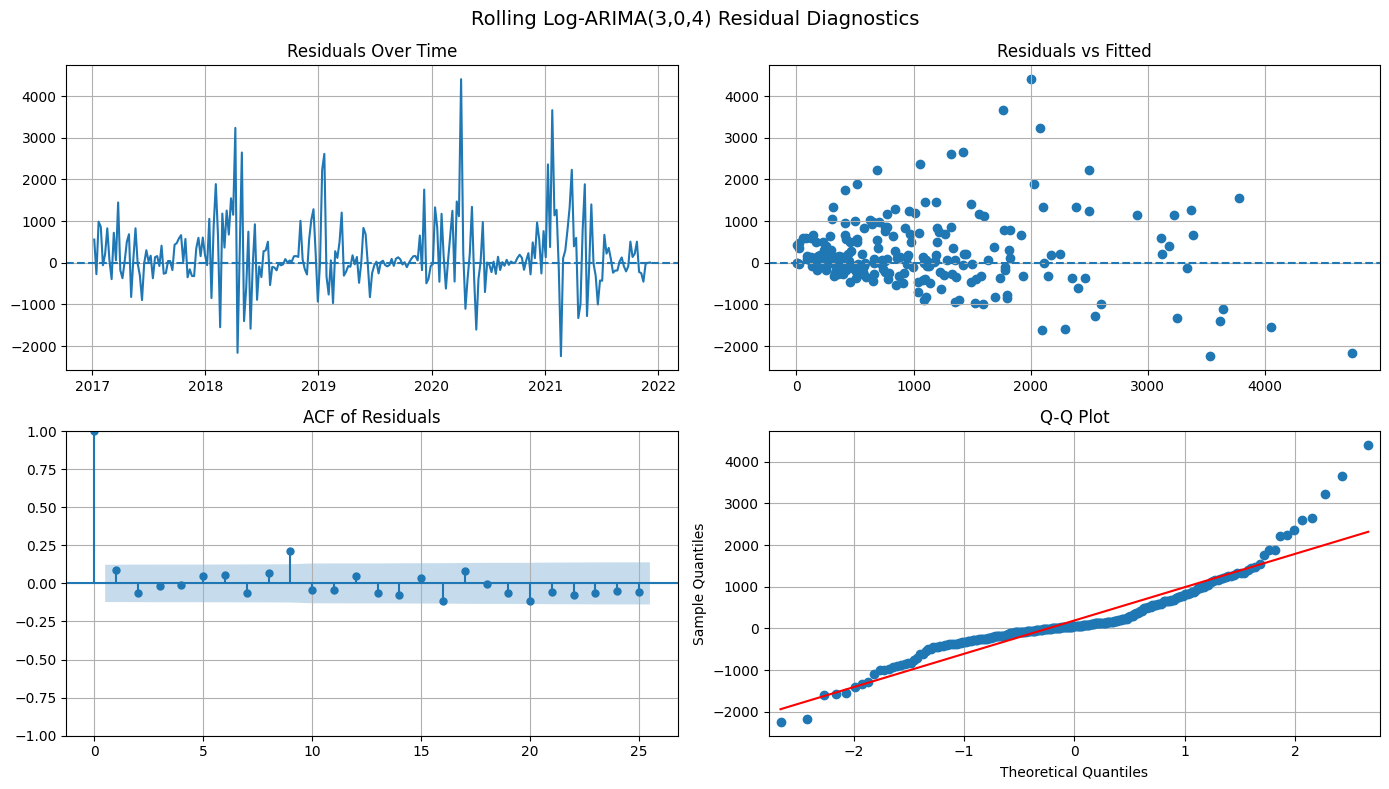

Ljung-Box Test:


,lb_stat,lb_pvalue
10,19.600452,0.033266
20,33.752599,0.027848


,lb_stat,lb_pvalue
10,19.600452,0.033266
20,33.752599,0.027848
30,44.142399,0.046294


In [50]:
rolling_log_arima_residuals = rolling_log_arima_true - rolling_log_arima_pred

residual_diagnostics(
    rolling_log_arima_residuals,
    fitted_values=rolling_log_arima_pred,
    title="Rolling Log-ARIMA(3,0,4) Residual Diagnostics"
)

acorr_ljungbox(
    rolling_log_arima_residuals.dropna(),
    lags=[10, 20, 30],
    return_df=True
)

#### SARIMA

In [51]:
# ============================================================
# SARIMA Modeling — Miami
# Research Question:
# Does explicitly modeling annual seasonality improve mosquito
# count forecasting compared with non-seasonal ARIMA?
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import time

In [52]:
# ============================================================
# Small SARIMA Hyperparameter Tuning
# ============================================================

def tune_sarima_small(train, seasonal_period=52):
    """
    Small SARIMA tuning grid designed to run in reasonable time.
    We keep the grid intentionally limited because SARIMA with weekly
    seasonality is computationally expensive.
    """
    
    candidate_orders = [
        (1, 0, 0),
        (1, 0, 1),
        (2, 0, 1),
        (3, 0, 1),
        (3, 0, 2),
        (3, 0, 4),   # from best ARIMA
    ]
    
    candidate_seasonal_orders = [
        (0, 0, 0, seasonal_period),  # no seasonal component
        (1, 0, 0, seasonal_period),  # seasonal AR
        (0, 0, 1, seasonal_period),  # seasonal MA
        (1, 0, 1, seasonal_period),  # seasonal ARMA
        (1, 1, 0, seasonal_period),  # seasonal differencing + seasonal AR
        (0, 1, 1, seasonal_period),  # seasonal differencing + seasonal MA
    ]
    
    results = []
    
    start_time = time.time()
    
    for order in candidate_orders:
        for seasonal_order in candidate_seasonal_orders:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                fitted = model.fit(disp=False, maxiter=75)
                
                results.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic
                })
                
                print(f"Finished SARIMA{order}{seasonal_order} | AIC: {fitted.aic:.2f}")
            
            except Exception as e:
                print(f"Failed SARIMA{order}{seasonal_order}: {e}")
                continue
    
    elapsed = time.time() - start_time
    print(f"\nTuning completed in {elapsed/60:.2f} minutes")
    
    results_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    return results_df


sarima_tuning_results = tune_sarima_small(
    train_series,
    seasonal_period=52
)

sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 3916.40
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 3132.46
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 3133.75
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 3132.66
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 2326.33
Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 4740.72
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 3879.52
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 3116.82
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 3102.01
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 3103.28
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 2322.06
Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 5784.79
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 3879.37
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 3101.29
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 3105.18
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 3101.22
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 2304.86
Finished SARIMA(2, 0, 1)(0, 1, 1, 52) | AIC: 5402.20
Finished SARIMA(3, 0, 1)(0, 0, 0, 52) | AIC: 3

,order,seasonal_order,AIC,BIC
0,"(3, 0, 4)","(1, 1, 0, 52)",2276.801876,2303.276658
1,"(3, 0, 2)","(1, 1, 0, 52)",2280.466258,2301.057755
2,"(3, 0, 1)","(1, 1, 0, 52)",2295.868932,2313.518786
3,"(2, 0, 1)","(1, 1, 0, 52)",2304.860669,2319.604469
4,"(1, 0, 1)","(1, 1, 0, 52)",2322.056221,2333.879529
5,"(1, 0, 0)","(1, 1, 0, 52)",2326.327684,2335.195165
6,"(3, 0, 4)","(1, 0, 1, 52)",3043.853103,3076.323344
7,"(3, 0, 4)","(0, 0, 1, 52)",3045.124008,3074.347225
8,"(3, 0, 4)","(1, 0, 0, 52)",3075.947398,3105.264857
9,"(3, 0, 2)","(1, 0, 1, 52)",3085.494693,3111.554656


In [53]:
# ============================================================
# Best One-Shot SARIMA Forecast
# ============================================================

best_sarima_order = sarima_tuning_results.iloc[0]["order"]
best_sarima_seasonal_order = sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best SARIMA order:", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

best_sarima = SARIMAX(
    train_series,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

sarima_forecast = best_sarima.forecast(steps=len(test_series))
sarima_forecast.index = test_series.index

sarima_metrics = compute_metrics(test_series, sarima_forecast)
print(sarima_metrics)
print("AIC:", best_sarima.aic)
print("BIC:", best_sarima.bic)

Best SARIMA order: (3, 0, 4)
Best SARIMA seasonal order: (1, 1, 0, 52)
{'RMSE': 1179.5599893330066, 'MAE': 791.1714166270241, 'R2': 0.2504412657820194, 'nRMSE': 0.8489293804618432, 'MAPE': 552.9544194134443, 'SMAPE': 75.71793266925347}
AIC: 2276.801876095259
BIC: 2303.276657898743


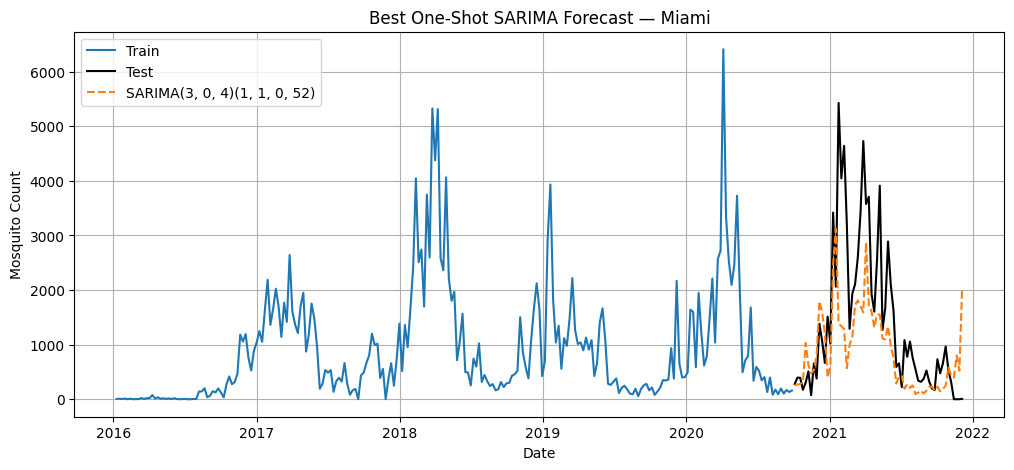

In [54]:
# ============================================================
# One-Shot SARIMA Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot SARIMA Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

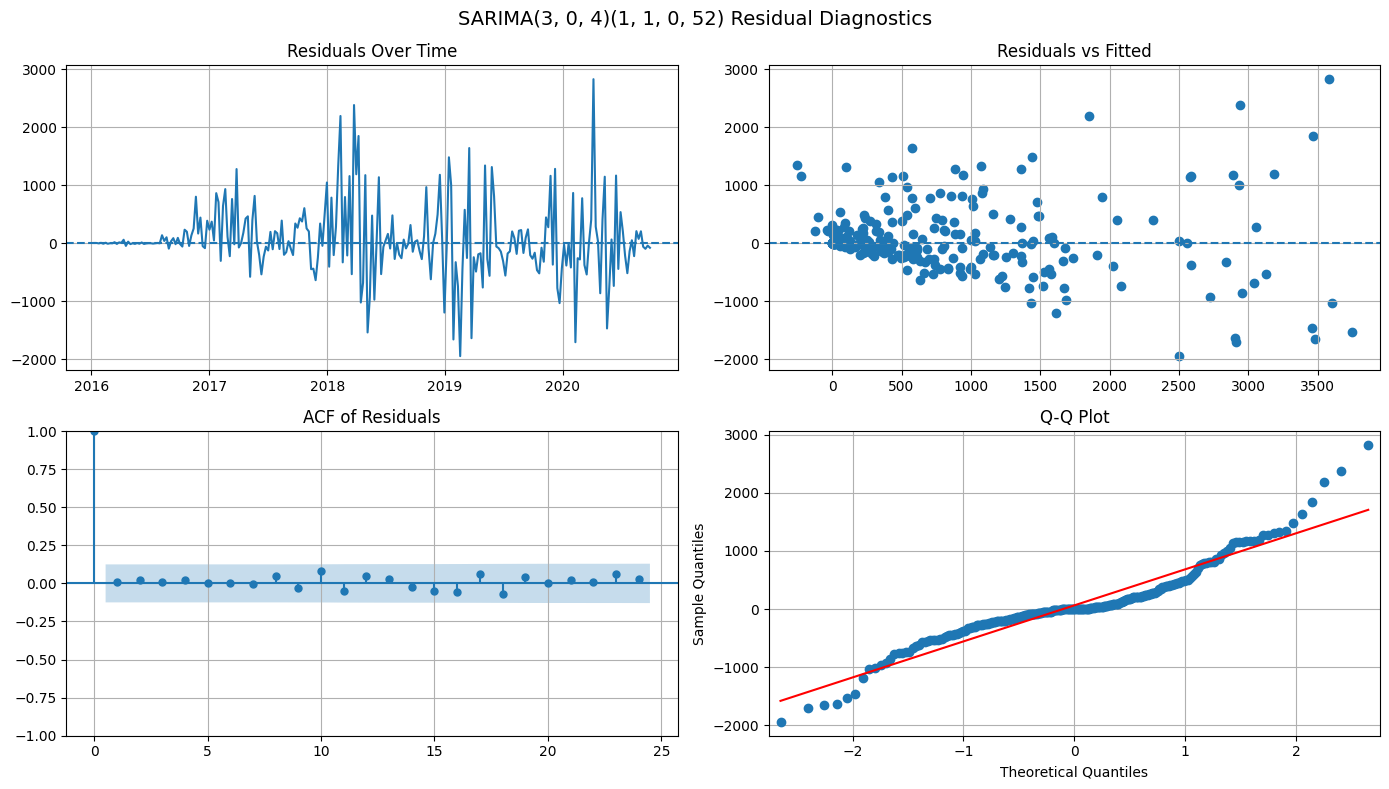

Ljung-Box Test:


,lb_stat,lb_pvalue
10,2.824445,0.985259
20,8.644934,0.986667


,lb_stat,lb_pvalue
10,2.824445,0.985259
20,8.644934,0.986667
30,12.664800,0.997675


In [55]:
# ============================================================
# One-Shot SARIMA Residual Diagnostics
# ============================================================

residual_diagnostics(
    best_sarima.resid,
    fitted_values=best_sarima.fittedvalues,
    title=f"SARIMA{best_sarima_order}{best_sarima_seasonal_order} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(best_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [57]:
# ============================================================
# Faster Rolling SARIMA Forecast
# Research Question:
# Does SARIMA improve real-time one-step-ahead surveillance forecasting?
# ============================================================

def fast_rolling_sarima_forecast(
    ts,
    order,
    seasonal_order,
    initial_train_size,
    refit_every=8,
    maxiter=25
):
    """
    Faster rolling one-step-ahead SARIMA forecast.

    Instead of refitting at every week, this refits every `refit_every`
    weeks and produces multi-step forecasts between refits.

    This keeps the rolling evaluation idea but runs much faster.
    """
    
    y_true, y_pred = [], []
    pred_index = []
    
    start_time = time.time()
    
    i = initial_train_size
    
    while i < len(ts):
        train = ts.iloc[:i]
        
        # Forecast block size
        steps = min(refit_every, len(ts) - i)
        test_block = ts.iloc[i:i + steps]
        
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                simple_differencing=True
            )
            
            fitted = model.fit(
                disp=False,
                maxiter=maxiter,
                method="powell"
            )
            
            forecast = fitted.forecast(steps=steps)
            forecast = np.maximum(forecast.values, 0)
        
        except Exception as e:
            # fallback: use last observed value for the whole block
            forecast = np.repeat(train.iloc[-1], steps)
        
        y_true.extend(test_block.values)
        y_pred.extend(forecast)
        pred_index.extend(test_block.index)
        
        print(f"Completed forecasts through index {i + steps} / {len(ts)}")
        
        i += steps
    
    elapsed = time.time() - start_time
    print(f"\nFast rolling SARIMA completed in {elapsed/60:.2f} minutes")
    
    return (
        np.array(y_true),
        np.array(y_pred),
        pd.Index(pred_index)
    )

In [58]:
# Use a faster SARIMA if the tuned one is too slow
fast_sarima_order = best_sarima_order
fast_sarima_seasonal_order = best_sarima_seasonal_order

# You can increase refit_every to 12 or 16 if still slow
y_true_roll_sarima, y_pred_roll_sarima, roll_sarima_index = fast_rolling_sarima_forecast(
    ts_series,
    order=fast_sarima_order,
    seasonal_order=fast_sarima_seasonal_order,
    initial_train_size=INITIAL_TRAIN_SIZE,
    refit_every=8,
    maxiter=25
)

rolling_sarima_metrics = compute_metrics(
    y_true_roll_sarima,
    y_pred_roll_sarima
)

print(rolling_sarima_metrics)

Completed forecasts through index 60 / 309
Completed forecasts through index 68 / 309
Completed forecasts through index 76 / 309
Completed forecasts through index 84 / 309
Completed forecasts through index 92 / 309
Completed forecasts through index 100 / 309
Completed forecasts through index 108 / 309
Completed forecasts through index 116 / 309
Completed forecasts through index 124 / 309
Completed forecasts through index 132 / 309
Completed forecasts through index 140 / 309
Completed forecasts through index 148 / 309
Completed forecasts through index 156 / 309
Completed forecasts through index 164 / 309
Completed forecasts through index 172 / 309
Completed forecasts through index 180 / 309
Completed forecasts through index 188 / 309
Completed forecasts through index 196 / 309
Completed forecasts through index 204 / 309
Completed forecasts through index 212 / 309
Completed forecasts through index 220 / 309
Completed forecasts through index 228 / 309
Completed forecasts through index 236

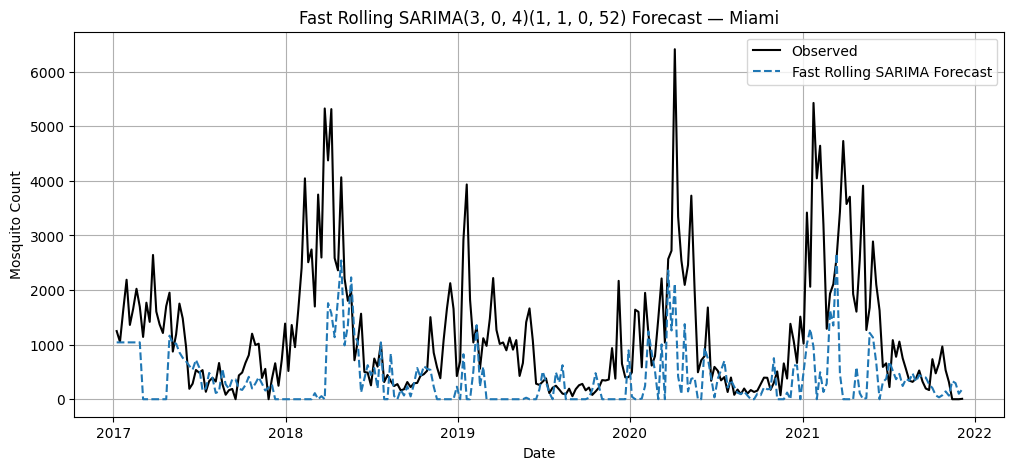

In [59]:
rolling_sarima_true = pd.Series(
    y_true_roll_sarima,
    index=roll_sarima_index,
    name="Observed"
)

rolling_sarima_pred = pd.Series(
    y_pred_roll_sarima,
    index=roll_sarima_index,
    name="Fast Rolling SARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(rolling_sarima_true.index, rolling_sarima_true, label="Observed", color="black")
plt.plot(rolling_sarima_pred.index, rolling_sarima_pred, label="Fast Rolling SARIMA Forecast", linestyle="--")

plt.title(f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

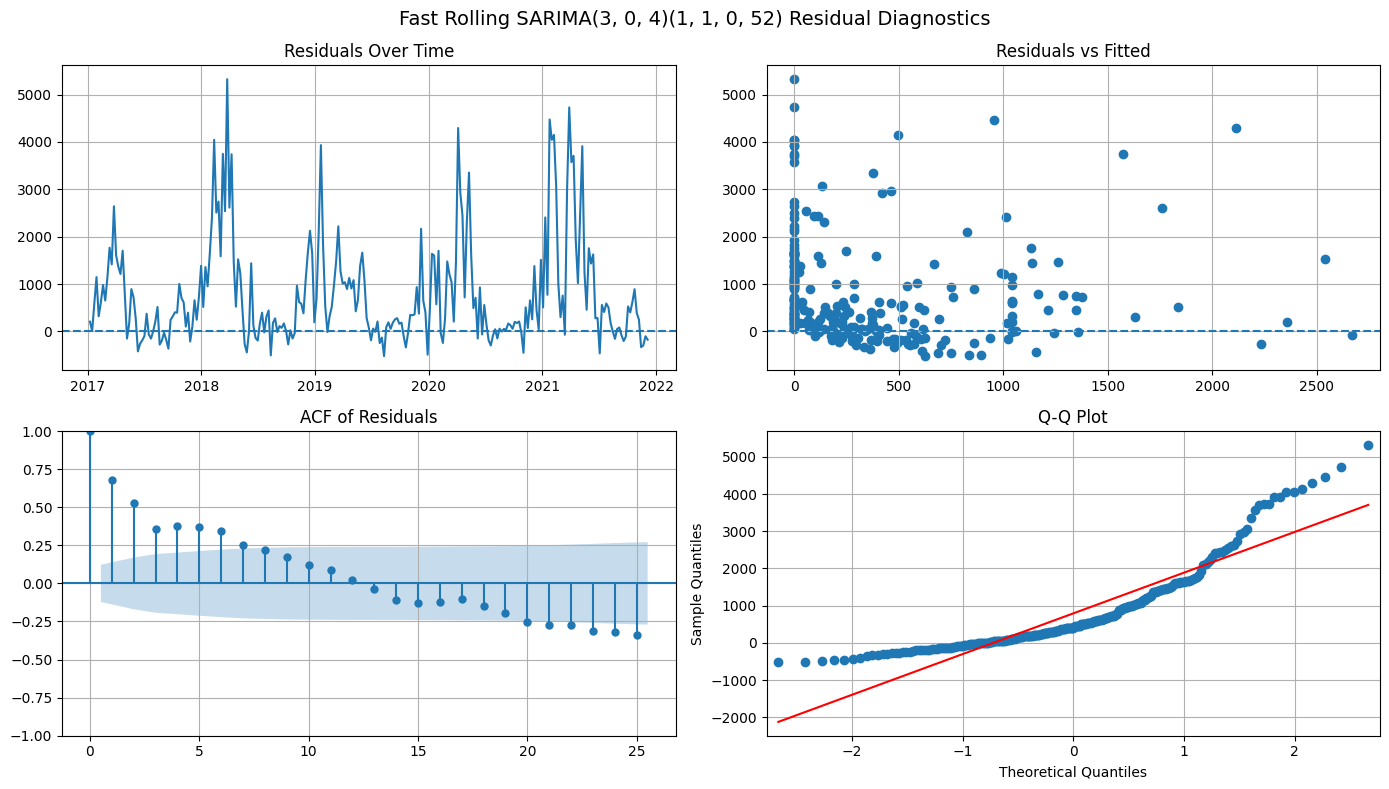

Ljung-Box Test:


,lb_stat,lb_pvalue
10,371.741693,9.623810e-74
20,423.877962,2.243654e-77


,lb_stat,lb_pvalue
10,371.741693,9.623810e-74
20,423.877962,2.243654e-77
30,736.849748,1.000838e-135


In [60]:
rolling_sarima_residuals = rolling_sarima_true - rolling_sarima_pred

residual_diagnostics(
    rolling_sarima_residuals,
    fitted_values=rolling_sarima_pred,
    title=f"Fast Rolling SARIMA{fast_sarima_order}{fast_sarima_seasonal_order} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        rolling_sarima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [61]:
# ============================================================
# Log-SARIMA Tuning
# Research Question:
# Does variance stabilization improve SARIMA performance?
# ============================================================

log_train_series = np.log1p(train_series)

log_sarima_tuning_results = tune_sarima_small(
    log_train_series,
    seasonal_period=52
)

log_sarima_tuning_results.head(10)

Finished SARIMA(1, 0, 0)(0, 0, 0, 52) | AIC: 743.32
Finished SARIMA(1, 0, 0)(1, 0, 0, 52) | AIC: 577.12
Finished SARIMA(1, 0, 0)(0, 0, 1, 52) | AIC: 578.57
Finished SARIMA(1, 0, 0)(1, 0, 1, 52) | AIC: 556.47
Finished SARIMA(1, 0, 0)(1, 1, 0, 52) | AIC: 411.61
Finished SARIMA(1, 0, 0)(0, 1, 1, 52) | AIC: 5418.04
Finished SARIMA(1, 0, 1)(0, 0, 0, 52) | AIC: 677.90
Finished SARIMA(1, 0, 1)(1, 0, 0, 52) | AIC: 520.60
Finished SARIMA(1, 0, 1)(0, 0, 1, 52) | AIC: 521.36
Finished SARIMA(1, 0, 1)(1, 0, 1, 52) | AIC: 511.96
Finished SARIMA(1, 0, 1)(1, 1, 0, 52) | AIC: 384.96
Finished SARIMA(1, 0, 1)(0, 1, 1, 52) | AIC: 5439.46
Finished SARIMA(2, 0, 1)(0, 0, 0, 52) | AIC: 679.36
Finished SARIMA(2, 0, 1)(1, 0, 0, 52) | AIC: 520.82
Finished SARIMA(2, 0, 1)(0, 0, 1, 52) | AIC: 523.50
Finished SARIMA(2, 0, 1)(1, 0, 1, 52) | AIC: 513.18
Finished SARIMA(2, 0, 1)(1, 1, 0, 52) | AIC: 381.52
Finished SARIMA(2, 0, 1)(0, 1, 1, 52) | AIC: 5441.46
Finished SARIMA(3, 0, 1)(0, 0, 0, 52) | AIC: 678.49
Finished 

,order,seasonal_order,AIC,BIC
0,"(3, 0, 4)","(1, 1, 0, 52)",374.771899,401.246681
1,"(3, 0, 1)","(1, 1, 0, 52)",381.203861,398.853715
2,"(2, 0, 1)","(1, 1, 0, 52)",381.521665,396.265465
3,"(3, 0, 2)","(1, 1, 0, 52)",383.031309,403.622806
4,"(1, 0, 1)","(1, 1, 0, 52)",384.957905,396.781214
5,"(1, 0, 0)","(1, 1, 0, 52)",411.605526,420.473008
6,"(1, 0, 1)","(1, 0, 1, 52)",511.957910,528.271361
7,"(3, 0, 4)","(1, 0, 1, 52)",512.336802,544.807043
8,"(3, 0, 2)","(1, 0, 1, 52)",512.746037,538.806000
9,"(2, 0, 1)","(1, 0, 1, 52)",513.182485,532.758626


In [62]:
# ============================================================
# Best One-Shot Log-SARIMA Forecast
# ============================================================

best_log_sarima_order = log_sarima_tuning_results.iloc[0]["order"]
best_log_sarima_seasonal_order = log_sarima_tuning_results.iloc[0]["seasonal_order"]

print("Best Log-SARIMA order:", best_log_sarima_order)
print("Best Log-SARIMA seasonal order:", best_log_sarima_seasonal_order)

best_log_sarima = SARIMAX(
    log_train_series,
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

log_sarima_forecast = best_log_sarima.forecast(steps=len(test_series))
log_sarima_forecast.index = test_series.index

# Back-transform to original count scale
log_sarima_forecast_original = np.expm1(log_sarima_forecast)
log_sarima_forecast_original = np.maximum(log_sarima_forecast_original, 0)

log_sarima_metrics = compute_metrics(
    test_series,
    log_sarima_forecast_original
)

print(log_sarima_metrics)
print("AIC:", best_log_sarima.aic)
print("BIC:", best_log_sarima.bic)

Best Log-SARIMA order: (3, 0, 4)
Best Log-SARIMA seasonal order: (1, 1, 0, 52)
{'RMSE': 1177.6416737866862, 'MAE': 763.497741574286, 'R2': 0.25287729441485707, 'nRMSE': 0.8475487686718579, 'MAPE': 571.8907619098801, 'SMAPE': 74.56821478977736}
AIC: 374.61368594958174
BIC: 401.08846775306546


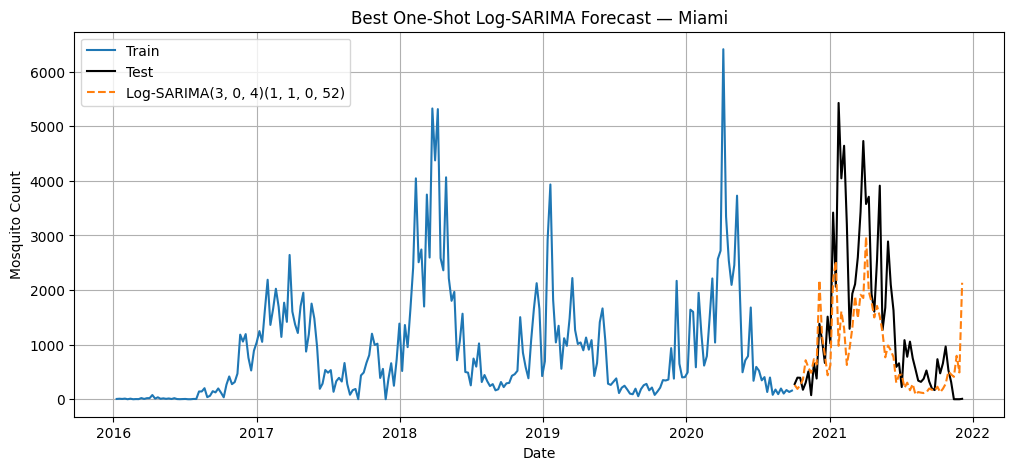

In [63]:
# ============================================================
# One-Shot Log-SARIMA Forecast Plot
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    log_sarima_forecast_original.index,
    log_sarima_forecast_original,
    label=f"Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order}",
    linestyle="--"
)

plt.title("Best One-Shot Log-SARIMA Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

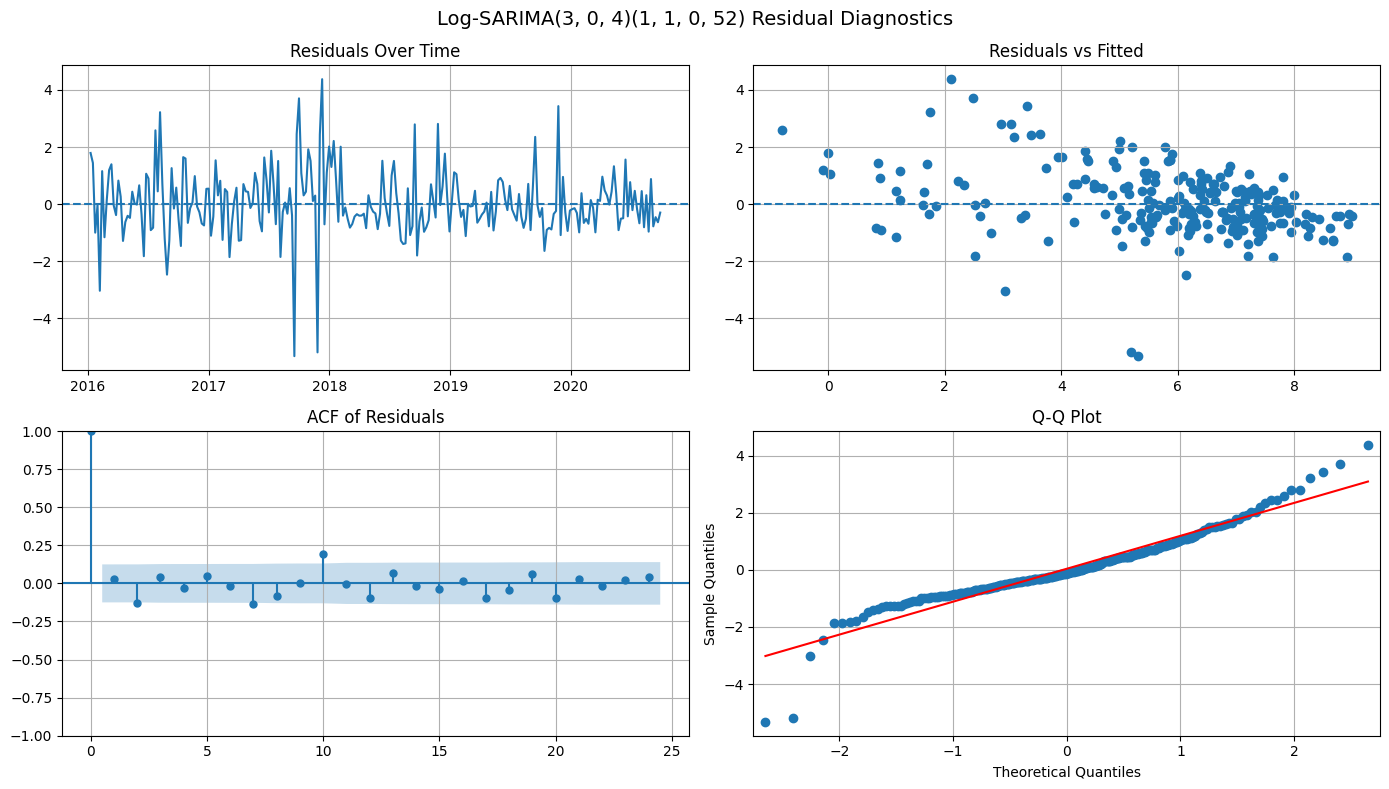

Ljung-Box Test:


,lb_stat,lb_pvalue
10,22.348850,0.013423
20,32.798981,0.035494


,lb_stat,lb_pvalue
10,22.348850,0.013423
20,32.798981,0.035494
30,37.279152,0.169147


In [64]:
# Diagnostics on log-scale residuals
residual_diagnostics(
    best_log_sarima.resid,
    fitted_values=best_log_sarima.fittedvalues,
    title=f"Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(best_log_sarima.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [ ]:
# ============================================================
# Rolling Log-SARIMA Forecast
# ============================================================

def rolling_log_sarima_forecast(ts, order, seasonal_order, initial_train_size):
    """
    Rolling one-step-ahead SARIMA on log1p-transformed counts.
    Forecasts are converted back to the original mosquito count scale.
    """
    
    y_true, y_pred = [], []
    
    start_time = time.time()
    
    for i in range(initial_train_size, len(ts)):
        train = ts.iloc[:i]
        test_value = ts.iloc[i]
        
        log_train = np.log1p(train)
        
        try:
            model = SARIMAX(
                log_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            fitted = model.fit(disp=False, maxiter=50)
            
            log_pred = fitted.forecast(steps=1).iloc[0]
            pred = np.expm1(log_pred)
            pred = max(pred, 0)
        
        except Exception as e:
            pred = train.iloc[-1]
        
        y_true.append(test_value)
        y_pred.append(pred)
        
        if (i - initial_train_size + 1) % 25 == 0:
            print(f"Completed {i - initial_train_size + 1} rolling log-SARIMA forecasts")
    
    elapsed = time.time() - start_time
    print(f"\nRolling Log-SARIMA completed in {elapsed/60:.2f} minutes")
    
    return np.array(y_true), np.array(y_pred)


y_true_roll_log_sarima, y_pred_roll_log_sarima = rolling_log_sarima_forecast(
    ts_series,
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    initial_train_size=INITIAL_TRAIN_SIZE
)

rolling_log_sarima_metrics = compute_metrics(
    y_true_roll_log_sarima,
    y_pred_roll_log_sarima
)

print(rolling_log_sarima_metrics)

In [ ]:
# ============================================================
# Rolling Log-SARIMA Forecast Plot
# ============================================================

rolling_log_sarima_index = ts_series.index[INITIAL_TRAIN_SIZE:]

rolling_log_sarima_true = pd.Series(
    y_true_roll_log_sarima,
    index=rolling_log_sarima_index,
    name="Observed"
)

rolling_log_sarima_pred = pd.Series(
    y_pred_roll_log_sarima,
    index=rolling_log_sarima_index,
    name="Rolling Log-SARIMA Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_log_sarima_true.index,
    rolling_log_sarima_true,
    label="Observed",
    color="black"
)

plt.plot(
    rolling_log_sarima_pred.index,
    rolling_log_sarima_pred,
    label="Rolling Log-SARIMA Forecast",
    linestyle="--"
)

plt.title(f"Rolling Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order} One-Step-Ahead Forecast — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Rolling Log-SARIMA Residual Diagnostics
# ============================================================

rolling_log_sarima_residuals = rolling_log_sarima_true - rolling_log_sarima_pred

residual_diagnostics(
    rolling_log_sarima_residuals,
    fitted_values=rolling_log_sarima_pred,
    title=f"Rolling Log-SARIMA{best_log_sarima_order}{best_log_sarima_seasonal_order} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        rolling_log_sarima_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [65]:
# ============================================================
# SARIMA Summary Table
# ============================================================

sarima_results = []

def add_sarima_result(model_name, order, seasonal_order, y_true, y_pred, fitted_model=None):
    metrics = compute_metrics(y_true, y_pred)
    
    sarima_results.append({
        "Model": model_name,
        "Order": str(order),
        "Seasonal_Order": str(seasonal_order),
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
        "nRMSE": metrics["nRMSE"],
        "MAPE": metrics["MAPE"],
        "SMAPE": metrics["SMAPE"],
        "AIC": fitted_model.aic if fitted_model is not None else np.nan,
        "BIC": fitted_model.bic if fitted_model is not None else np.nan
    })


add_sarima_result(
    model_name="SARIMA One-Shot",
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    y_true=test_series,
    y_pred=sarima_forecast,
    fitted_model=best_sarima
)

add_sarima_result(
    model_name="Rolling SARIMA",
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    y_true=y_true_roll_sarima,
    y_pred=y_pred_roll_sarima,
    fitted_model=None
)

add_sarima_result(
    model_name="Log-SARIMA One-Shot",
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    y_true=test_series,
    y_pred=log_sarima_forecast_original,
    fitted_model=best_log_sarima
)

'''

add_sarima_result(
    model_name="Rolling Log-SARIMA",
    order=best_log_sarima_order,
    seasonal_order=best_log_sarima_seasonal_order,
    y_true=y_true_roll_log_sarima,
    y_pred=y_pred_roll_log_sarima,
    fitted_model=None
)
'''
sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df = sarima_results_df.sort_values("RMSE").reset_index(drop=True)

sarima_results_df

,Model,Order,Seasonal_Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",1177.641674,763.497742,0.252877,0.847549,571.890762,74.568215,374.613686,401.088468
1,SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",1179.559989,791.171417,0.250441,0.848929,552.954419,75.717933,2276.801876,2303.276658
2,Rolling SARIMA,"(3, 0, 4)","(1, 1, 0, 52)",1352.351494,872.088481,-0.362836,1.157939,83.394356,117.619898,NaN,NaN


In [66]:
sarima_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Order,Seasonal_Order,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",1177.64,763.50,0.253,0.848,571.89,74.57,374.61,401.09
1,SARIMA One-Shot,"(3, 0, 4)","(1, 1, 0, 52)",1179.56,791.17,0.250,0.849,552.95,75.72,2276.80,2303.28
2,Rolling SARIMA,"(3, 0, 4)","(1, 1, 0, 52)",1352.35,872.09,-0.363,1.158,83.39,117.62,nan,nan


#### ETS 

In [68]:
# ============================================================
# ETS Model Variations
# Research Question:
# Can smoothing-based models capture mosquito count dynamics better
# than ARIMA-family models?
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_results = []
ets_fits = {}
ets_forecasts = {}

ets_configs = [
    {"trend": None, "seasonal": None, "damped_trend": False, "name": "ETS Simple"},
    {"trend": "add", "seasonal": None, "damped_trend": False, "name": "ETS Additive Trend"},
    {"trend": "add", "seasonal": None, "damped_trend": True, "name": "ETS Damped Trend"},
    {"trend": None, "seasonal": "add", "damped_trend": False, "name": "ETS Additive Seasonality"},
    {"trend": "add", "seasonal": "add", "damped_trend": False, "name": "ETS Add Trend + Add Season"},
    {"trend": "add", "seasonal": "add", "damped_trend": True, "name": "ETS Damped Trend + Add Season"},
]

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)
        forecast = fitted.forecast(len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        ets_results.append({
            "Model": config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        ets_fits[config["name"]] = fitted
        ets_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

ets_results_df = pd.DataFrame(ets_results).sort_values("RMSE").reset_index(drop=True)
ets_results_df

ETS Simple {'RMSE': 1841.5166447316778, 'MAE': 1260.5956364929448, 'R2': -0.8269089384380968, 'nRMSE': 1.3253396168568148, 'MAPE': 110.63639766909385, 'SMAPE': 135.73513186611822}
ETS Additive Trend {'RMSE': 1831.0203720145425, 'MAE': 1246.7080916265577, 'R2': -0.8061422670138783, 'nRMSE': 1.3177854488827427, 'MAPE': 117.11070207129555, 'SMAPE': 130.41012133463872}
ETS Damped Trend {'RMSE': 1835.8837906150893, 'MAE': 1253.257429673598, 'R2': -0.8157496878438502, 'nRMSE': 1.3212856514810212, 'MAPE': 113.13283873362198, 'SMAPE': 132.96551018050903}
ETS Additive Seasonality {'RMSE': 1085.0190884272276, 'MAE': 714.9041694419814, 'R2': 0.36577937577478126, 'nRMSE': 0.7808882895804626, 'MAPE': 324.4118229349633, 'SMAPE': 72.19378469191675}
ETS Add Trend + Add Season {'RMSE': 1039.1175877999399, 'MAE': 672.2631283221946, 'R2': 0.4183054502352601, 'nRMSE': 0.7478529773944104, 'MAPE': 383.83766638230543, 'SMAPE': 58.89893221583}
ETS Damped Trend + Add Season {'RMSE': 1085.0367735867019, 'MAE': 

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,1039.117588,672.263128,0.418305,0.747853,383.837666,58.898932,3244.552089,3441.077835
1,ETS Additive Seasonality,None,add,False,1085.019088,714.904169,0.365779,0.780888,324.411823,72.193785,3240.568525,3430.075496
2,ETS Damped Trend + Add Season,add,add,True,1085.036774,716.892534,0.365759,0.780901,318.102607,72.455580,3246.412287,3446.447423
3,ETS Additive Trend,add,None,False,1831.020372,1246.708092,-0.806142,1.317785,117.110702,130.410121,3214.820721,3228.858275
4,ETS Damped Trend,add,None,True,1835.883791,1253.257430,-0.815750,1.321286,113.132839,132.965510,3216.737956,3234.284898
5,ETS Simple,None,None,False,1841.516645,1260.595636,-0.826909,1.325340,110.636398,135.735132,3210.821411,3217.840187


In [69]:
ets_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,1039.12,672.26,0.418,0.748,383.84,58.90,3244.55,3441.08
1,ETS Additive Seasonality,None,add,False,1085.02,714.90,0.366,0.781,324.41,72.19,3240.57,3430.08
2,ETS Damped Trend + Add Season,add,add,True,1085.04,716.89,0.366,0.781,318.10,72.46,3246.41,3446.45
3,ETS Additive Trend,add,None,False,1831.02,1246.71,-0.806,1.318,117.11,130.41,3214.82,3228.86
4,ETS Damped Trend,add,None,True,1835.88,1253.26,-0.816,1.321,113.13,132.97,3216.74,3234.28
5,ETS Simple,None,None,False,1841.52,1260.60,-0.827,1.325,110.64,135.74,3210.82,3217.84


In [70]:
best_ets_name = ets_results_df.iloc[0]["Model"]
best_ets_model = ets_fits[best_ets_name]
best_ets_forecast = ets_forecasts[best_ets_name]

print("Best ETS model:", best_ets_name)
print(ets_results_df.iloc[0])

Best ETS model: ETS Add Trend + Add Season
Model           ETS Add Trend + Add Season
Trend                                  add
Seasonal                               add
Damped_Trend                         False
RMSE                           1039.117588
MAE                             672.263128
R2                                0.418305
nRMSE                             0.747853
MAPE                            383.837666
SMAPE                            58.898932
AIC                            3244.552089
BIC                            3441.077835
Name: 0, dtype: object


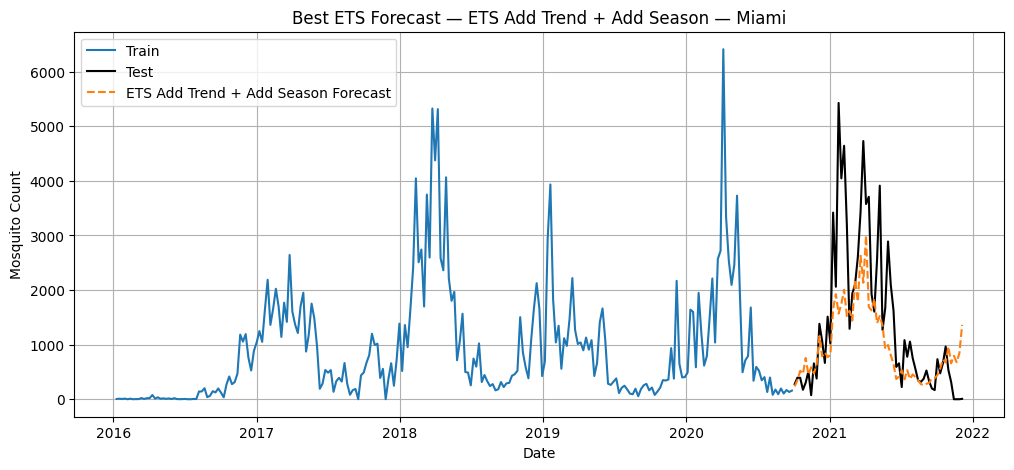

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_ets_forecast.index,
    best_ets_forecast,
    label=f"{best_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best ETS Forecast — {best_ets_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

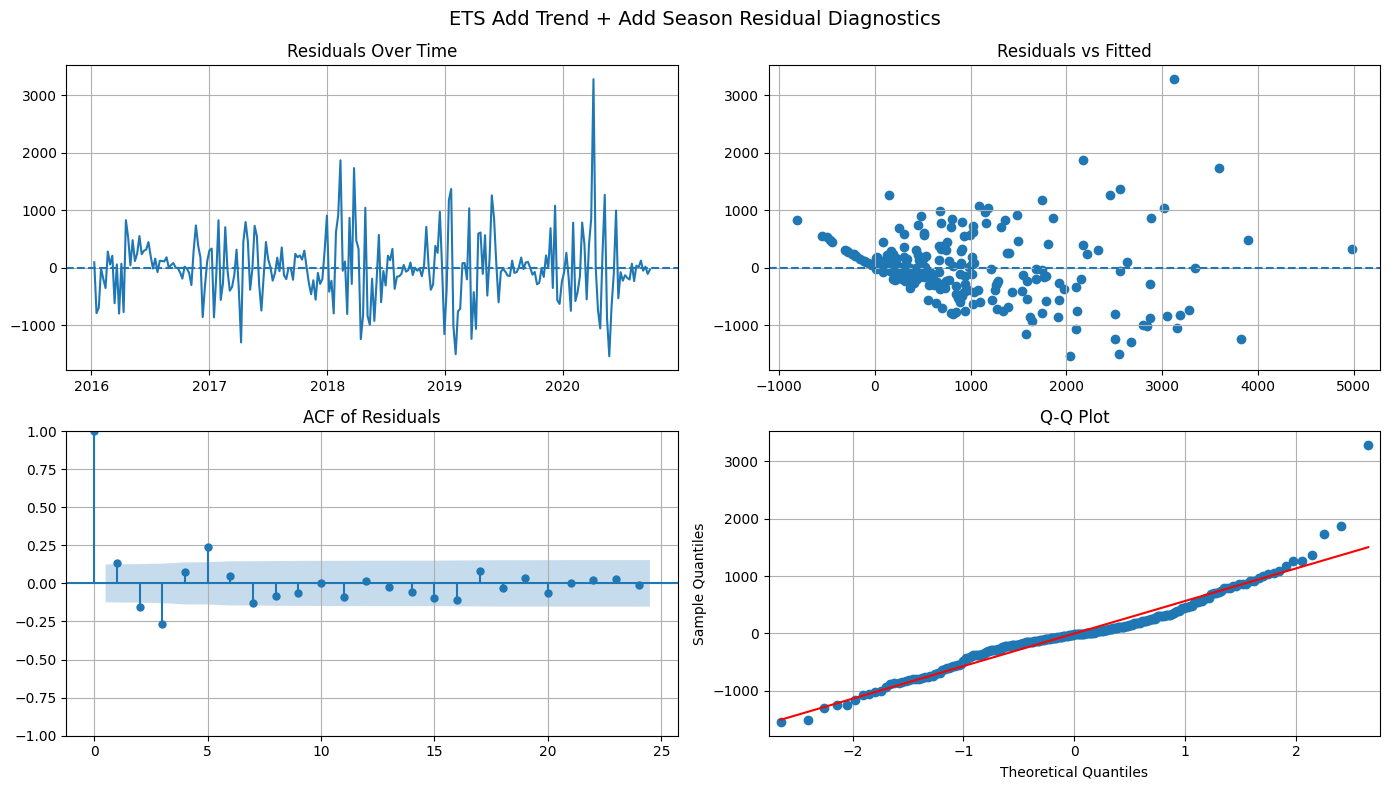

Ljung-Box Test:


,lb_stat,lb_pvalue
10,52.081953,1.101936e-07
20,64.063128,1.644320e-06


,lb_stat,lb_pvalue
10,52.081953,1.101936e-07
20,64.063128,1.644320e-06
30,69.130920,6.340665e-05


In [72]:
residual_diagnostics(
    best_ets_model.resid,
    fitted_values=best_ets_model.fittedvalues,
    title=f"{best_ets_name} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(best_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [73]:
# ============================================================
# Log-ETS Model Variations
# Research Question:
# Does variance stabilization improve ETS performance?
# ============================================================

log_train_series = np.log1p(train_series)

log_ets_results = []
log_ets_fits = {}
log_ets_forecasts = {}

for config in ets_configs:
    try:
        model = ExponentialSmoothing(
            log_train_series,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=52 if config["seasonal"] is not None else None,
            damped_trend=config["damped_trend"],
            initialization_method="estimated"
        )

        fitted = model.fit(optimized=True)

        log_forecast = fitted.forecast(len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        log_ets_results.append({
            "Model": "Log-" + config["name"],
            "Trend": config["trend"],
            "Seasonal": config["seasonal"],
            "Damped_Trend": config["damped_trend"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_ets_fits["Log-" + config["name"]] = fitted
        log_ets_forecasts["Log-" + config["name"]] = forecast_original

        print("Log-" + config["name"], metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_ets_results_df = pd.DataFrame(log_ets_results).sort_values("RMSE").reset_index(drop=True)
log_ets_results_df

Log-ETS Simple {'RMSE': 1843.2560692461489, 'MAE': 1262.7628377842423, 'R2': -0.8303618216916551, 'nRMSE': 1.3265914807626642, 'MAPE': 110.33745625166817, 'SMAPE': 136.49935982728064}
Log-ETS Additive Trend {'RMSE': 1803.0119743746773, 'MAE': 1211.1152874102243, 'R2': -0.7513091851839773, 'nRMSE': 1.2976278037683262, 'MAPE': 147.1488559613421, 'SMAPE': 118.2694629174093}
Log-ETS Damped Trend {'RMSE': 1840.4283947040842, 'MAE': 1259.0988478110216, 'R2': -0.8247503413258372, 'nRMSE': 1.3245564032601624, 'MAPE': 111.56804330946582, 'SMAPE': 135.09657323163654}
Log-ETS Additive Seasonality {'RMSE': 1471.635873196539, 'MAE': 997.3901263661768, 'R2': -0.1667191737072511, 'nRMSE': 1.0591364079792147, 'MAPE': 245.01631240224575, 'SMAPE': 99.00832954947766}
Log-ETS Add Trend + Add Season {'RMSE': 1259.9971393178416, 'MAE': 824.9191897729455, 'R2': 0.14472707965762888, 'nRMSE': 0.9068200011341797, 'MAPE': 698.1281610399402, 'SMAPE': 70.81962603201401}
Log-ETS Damped Trend + Add Season {'RMSE': 1

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-ETS Add Trend + Add Season,add,add,False,1259.997139,824.919190,0.144727,0.906820,698.128161,70.819626,13.168097,209.693843
1,Log-ETS Damped Trend + Add Season,add,add,True,1419.812167,960.518341,-0.085994,1.021839,273.957211,94.587670,12.257555,212.292690
2,Log-ETS Additive Seasonality,None,add,False,1471.635873,997.390126,-0.166719,1.059136,245.016312,99.008330,9.970612,199.477582
3,Log-ETS Additive Trend,add,None,False,1803.011974,1211.115287,-0.751309,1.297628,147.148856,118.269463,-18.006455,-3.968901
4,Log-ETS Damped Trend,add,None,True,1840.428395,1259.098848,-0.824750,1.324556,111.568043,135.096573,-17.161652,0.385290
5,Log-ETS Simple,None,None,False,1843.256069,1262.762838,-0.830362,1.326591,110.337456,136.499360,-21.793651,-14.774874


In [74]:
all_ets_results_df = pd.concat(
    [ets_results_df, log_ets_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_ets_results_df

,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,1039.117588,672.263128,0.418305,0.747853,383.837666,58.898932,3244.552089,3441.077835
1,ETS Additive Seasonality,None,add,False,1085.019088,714.904169,0.365779,0.780888,324.411823,72.193785,3240.568525,3430.075496
2,ETS Damped Trend + Add Season,add,add,True,1085.036774,716.892534,0.365759,0.780901,318.102607,72.455580,3246.412287,3446.447423
3,Log-ETS Add Trend + Add Season,add,add,False,1259.997139,824.919190,0.144727,0.906820,698.128161,70.819626,13.168097,209.693843
4,Log-ETS Damped Trend + Add Season,add,add,True,1419.812167,960.518341,-0.085994,1.021839,273.957211,94.587670,12.257555,212.292690
5,Log-ETS Additive Seasonality,None,add,False,1471.635873,997.390126,-0.166719,1.059136,245.016312,99.008330,9.970612,199.477582
6,Log-ETS Additive Trend,add,None,False,1803.011974,1211.115287,-0.751309,1.297628,147.148856,118.269463,-18.006455,-3.968901
7,ETS Additive Trend,add,None,False,1831.020372,1246.708092,-0.806142,1.317785,117.110702,130.410121,3214.820721,3228.858275
8,ETS Damped Trend,add,None,True,1835.883791,1253.257430,-0.815750,1.321286,113.132839,132.965510,3216.737956,3234.284898
9,Log-ETS Damped Trend,add,None,True,1840.428395,1259.098848,-0.824750,1.324556,111.568043,135.096573,-17.161652,0.385290


In [75]:
best_overall_ets_name = all_ets_results_df.iloc[0]["Model"]

if best_overall_ets_name.startswith("Log-"):
    best_overall_ets_model = log_ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = log_ets_forecasts[best_overall_ets_name]
else:
    best_overall_ets_model = ets_fits[best_overall_ets_name]
    best_overall_ets_forecast = ets_forecasts[best_overall_ets_name]

print("Best overall ETS model:", best_overall_ets_name)
display(all_ets_results_df.iloc[[0]])

Best overall ETS model: ETS Add Trend + Add Season


,Model,Trend,Seasonal,Damped_Trend,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,ETS Add Trend + Add Season,add,add,False,1039.117588,672.263128,0.418305,0.747853,383.837666,58.898932,3244.552089,3441.077835


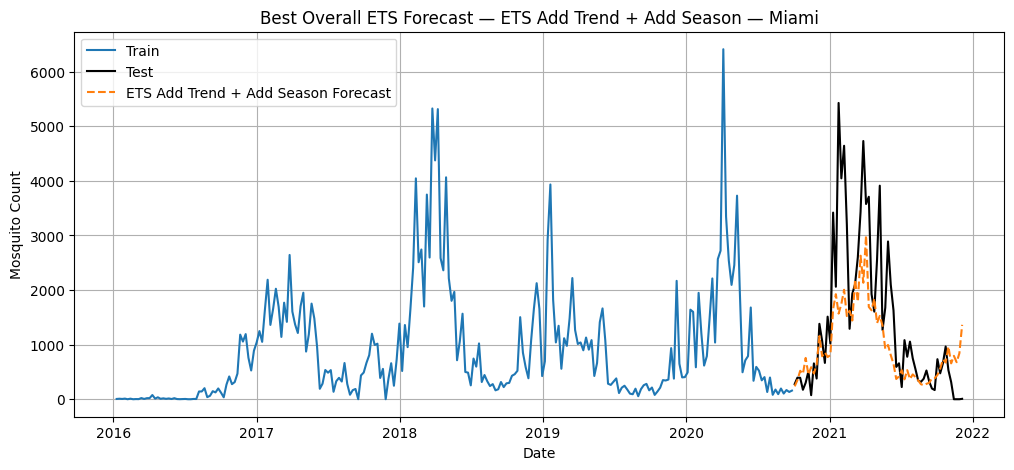

In [76]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_overall_ets_forecast.index,
    best_overall_ets_forecast,
    label=f"{best_overall_ets_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall ETS Forecast — {best_overall_ets_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

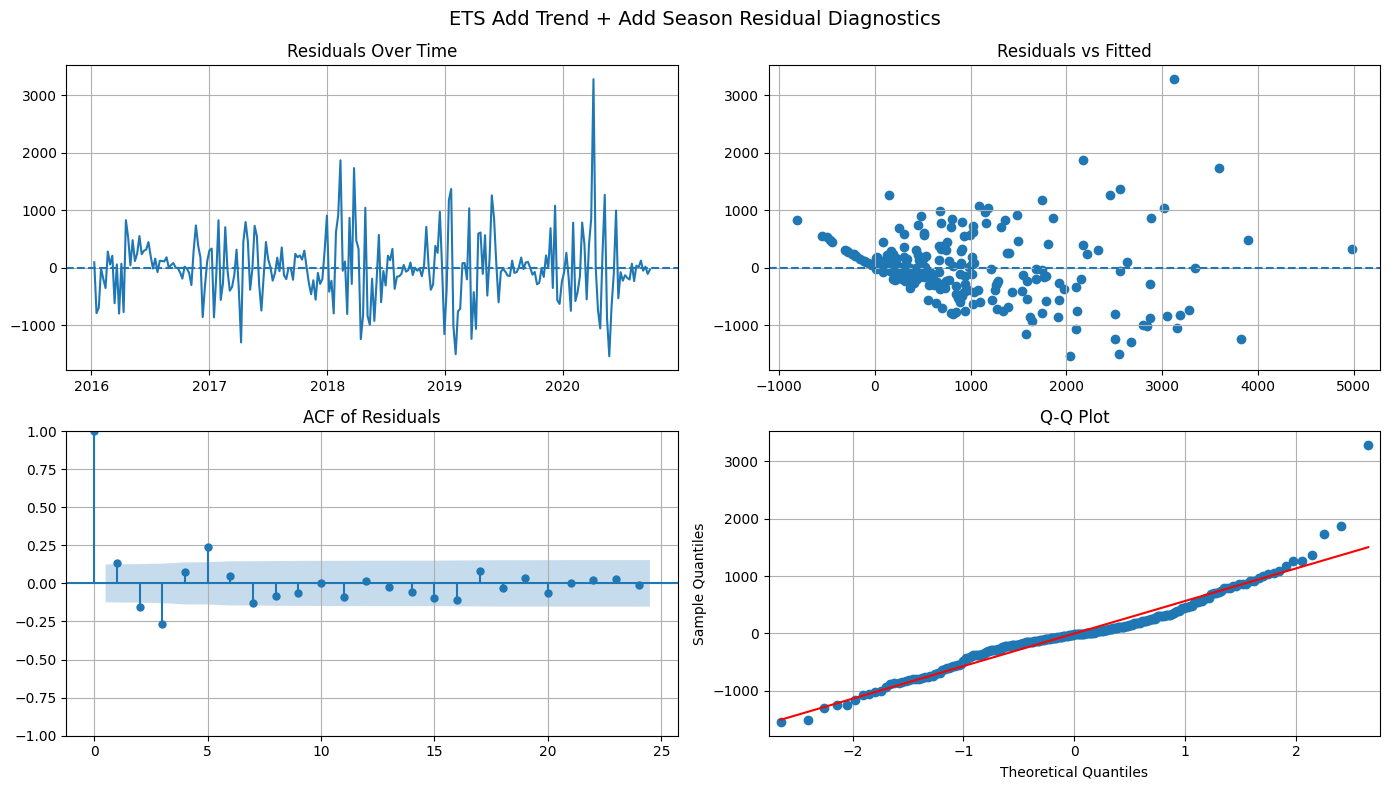

Ljung-Box Test:


,lb_stat,lb_pvalue
10,52.081953,1.101936e-07
20,64.063128,1.644320e-06


,lb_stat,lb_pvalue
10,52.081953,1.101936e-07
20,64.063128,1.644320e-06
30,69.130920,6.340665e-05


In [77]:
residual_diagnostics(
    best_overall_ets_model.resid,
    fitted_values=best_overall_ets_model.fittedvalues,
    title=f"{best_overall_ets_name} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(best_overall_ets_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [78]:
add_result(
    best_overall_ets_name,
    test_series,
    best_overall_ets_forecast
)

{'RMSE': 1039.1175877999399,
 'MAE': 672.2631283221946,
 'R2': 0.4183054502352601,
 'nRMSE': 0.7478529773944104,
 'MAPE': 383.83766638230543,
 'SMAPE': 58.89893221583}

#### Structural State Space Model

In [79]:
# ============================================================
# Structural State Space Model Variations
# Research Question:
# Can interpretable decomposition into trend and seasonality
# explain mosquito abundance?
# ============================================================

structural_results = []
structural_fits = {}
structural_forecasts = {}

structural_configs = [
    {"level": "local level", "trend": False, "seasonal": None, "name": "Local Level"},
    {"level": "local linear trend", "trend": True, "seasonal": None, "name": "Local Linear Trend"},
    {"level": "local level", "trend": False, "seasonal": 52, "name": "Local Level + Seasonal"},
    {"level": "local linear trend", "trend": True, "seasonal": 52, "name": "Local Linear Trend + Seasonal"},
]

for config in structural_configs:
    try:
        model = UnobservedComponents(
            train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(steps=len(test_series))
        forecast.index = test_series.index
        forecast = np.maximum(forecast, 0)

        metrics = compute_metrics(test_series, forecast)

        structural_results.append({
            "Model": config["name"],
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        structural_fits[config["name"]] = fitted
        structural_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

structural_results_df = pd.DataFrame(structural_results).sort_values("RMSE").reset_index(drop=True)
structural_results_df

Local Level {'RMSE': 1841.5263867621225, 'MAE': 1260.6077812646233, 'R2': -0.8269282679941183, 'nRMSE': 1.3253466281965893, 'MAPE': 110.63472243233834, 'SMAPE': 135.73939872270765}
Local Linear Trend {'RMSE': 1830.9817556829664, 'MAE': 1246.6611192186863, 'R2': -0.8060660845155918, 'nRMSE': 1.3177576567070695, 'MAPE': 117.11999600085502, 'SMAPE': 130.39479817552893}
Local Level + Seasonal {'RMSE': 1573.635914782033, 'MAE': 1083.8898786282177, 'R2': -0.33405618627551403, 'nRMSE': 1.1325458427627897, 'MAPE': 239.97483954823787, 'SMAPE': 114.34709483433132}
Local Linear Trend + Seasonal {'RMSE': 1552.6738495820848, 'MAE': 1057.4721512621222, 'R2': -0.2987515551726603, 'nRMSE': 1.117459443440738, 'MAPE': 258.15855138504065, 'SMAPE': 104.86193178014958}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Local Linear Trend + Seasonal,local linear trend,52.0,1552.673850,1057.472151,-0.298752,1.117459,258.158551,104.861932,3141.424027,3154.495459
1,Local Level + Seasonal,local level,52.0,1573.635915,1083.889879,-0.334056,1.132546,239.974840,114.347095,3153.465361,3163.284359
2,Local Linear Trend,local linear trend,NaN,1830.981756,1246.661119,-0.806066,1.317758,117.119996,130.394798,3890.609498,3901.113273
3,Local Level,local level,NaN,1841.526387,1260.607781,-0.826928,1.325347,110.634722,135.739399,3897.119911,3904.130574


In [80]:
# ============================================================
# Log-Structural State Space Variations
# ============================================================

log_structural_results = []
log_structural_fits = {}
log_structural_forecasts = {}

log_train_series = np.log1p(train_series)

for config in structural_configs:
    try:
        model = UnobservedComponents(
            log_train_series,
            level=config["level"],
            seasonal=config["seasonal"]
        )

        fitted = model.fit(disp=False)

        log_forecast = fitted.forecast(steps=len(test_series))
        log_forecast.index = test_series.index

        forecast_original = np.expm1(log_forecast)
        forecast_original = np.maximum(forecast_original, 0)

        metrics = compute_metrics(test_series, forecast_original)

        model_name = "Log-" + config["name"]

        log_structural_results.append({
            "Model": model_name,
            "Level": config["level"],
            "Seasonal": config["seasonal"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

        log_structural_fits[model_name] = fitted
        log_structural_forecasts[model_name] = forecast_original

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", "Log-" + config["name"], "|", e)

log_structural_results_df = pd.DataFrame(log_structural_results).sort_values("RMSE").reset_index(drop=True)
log_structural_results_df

Log-Local Level {'RMSE': 1843.2412120306424, 'MAE': 1262.7443371774561, 'R2': -0.8303323152428257, 'nRMSE': 1.326580788023957, 'MAPE': 110.34000820548906, 'SMAPE': 136.4928117987493}
Log-Local Linear Trend {'RMSE': 1811.7973030663213, 'MAE': 1222.0423480075258, 'R2': -0.7684175698475422, 'nRMSE': 1.303950605245823, 'MAPE': 136.60769354263266, 'SMAPE': 121.73308246350916}
Log-Local Level + Seasonal {'RMSE': 1469.932950816586, 'MAE': 996.0969779267604, 'R2': -0.16402056777628826, 'nRMSE': 1.0579108146613154, 'MAPE': 245.71879603417415, 'SMAPE': 98.8296742232279}
Log-Local Linear Trend + Seasonal {'RMSE': 1365.2628283494141, 'MAE': 916.746099424043, 'R2': -0.004148942759054641, 'nRMSE': 0.9825797225401195, 'MAPE': 368.6708966716583, 'SMAPE': 86.05295706896618}


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,1365.262828,916.746099,-0.004149,0.982580,368.670897,86.052957,608.702278,621.773711
1,Log-Local Level + Seasonal,local level,52.0,1469.932951,996.096978,-0.164021,1.057911,245.718796,98.829674,609.708616,619.527615
2,Log-Local Linear Trend,local linear trend,NaN,1811.797303,1222.042348,-0.768418,1.303951,136.607694,121.733082,684.870393,695.374167
3,Log-Local Level,local level,NaN,1843.241212,1262.744337,-0.830332,1.326581,110.340008,136.492812,677.774767,684.785430


In [82]:
all_structural_results_df = pd.concat(
    [structural_results_df, log_structural_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_structural_results_df

,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,1365.262828,916.746099,-0.004149,0.982580,368.670897,86.052957,608.702278,621.773711
1,Log-Local Level + Seasonal,local level,52.0,1469.932951,996.096978,-0.164021,1.057911,245.718796,98.829674,609.708616,619.527615
2,Local Linear Trend + Seasonal,local linear trend,52.0,1552.673850,1057.472151,-0.298752,1.117459,258.158551,104.861932,3141.424027,3154.495459
3,Local Level + Seasonal,local level,52.0,1573.635915,1083.889879,-0.334056,1.132546,239.974840,114.347095,3153.465361,3163.284359
4,Log-Local Linear Trend,local linear trend,NaN,1811.797303,1222.042348,-0.768418,1.303951,136.607694,121.733082,684.870393,695.374167
5,Local Linear Trend,local linear trend,NaN,1830.981756,1246.661119,-0.806066,1.317758,117.119996,130.394798,3890.609498,3901.113273
6,Local Level,local level,NaN,1841.526387,1260.607781,-0.826928,1.325347,110.634722,135.739399,3897.119911,3904.130574
7,Log-Local Level,local level,NaN,1843.241212,1262.744337,-0.830332,1.326581,110.340008,136.492812,677.774767,684.785430


In [83]:
best_structural_name = all_structural_results_df.iloc[0]["Model"]

if best_structural_name.startswith("Log-"):
    best_structural_model = log_structural_fits[best_structural_name]
    best_structural_forecast = log_structural_forecasts[best_structural_name]
else:
    best_structural_model = structural_fits[best_structural_name]
    best_structural_forecast = structural_forecasts[best_structural_name]

print("Best Structural Model:", best_structural_name)
display(all_structural_results_df.iloc[[0]])

Best Structural Model: Log-Local Linear Trend + Seasonal


,Model,Level,Seasonal,RMSE,MAE,R2,nRMSE,MAPE,SMAPE,AIC,BIC
0,Log-Local Linear Trend + Seasonal,local linear trend,52.0,1365.262828,916.746099,-0.004149,0.98258,368.670897,86.052957,608.702278,621.773711


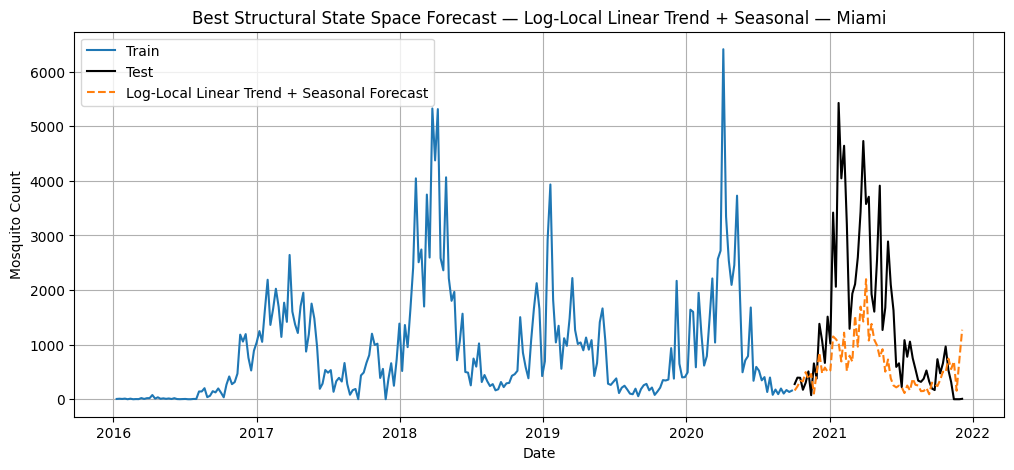

In [84]:
plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    best_structural_forecast.index,
    best_structural_forecast,
    label=f"{best_structural_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Structural State Space Forecast — {best_structural_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

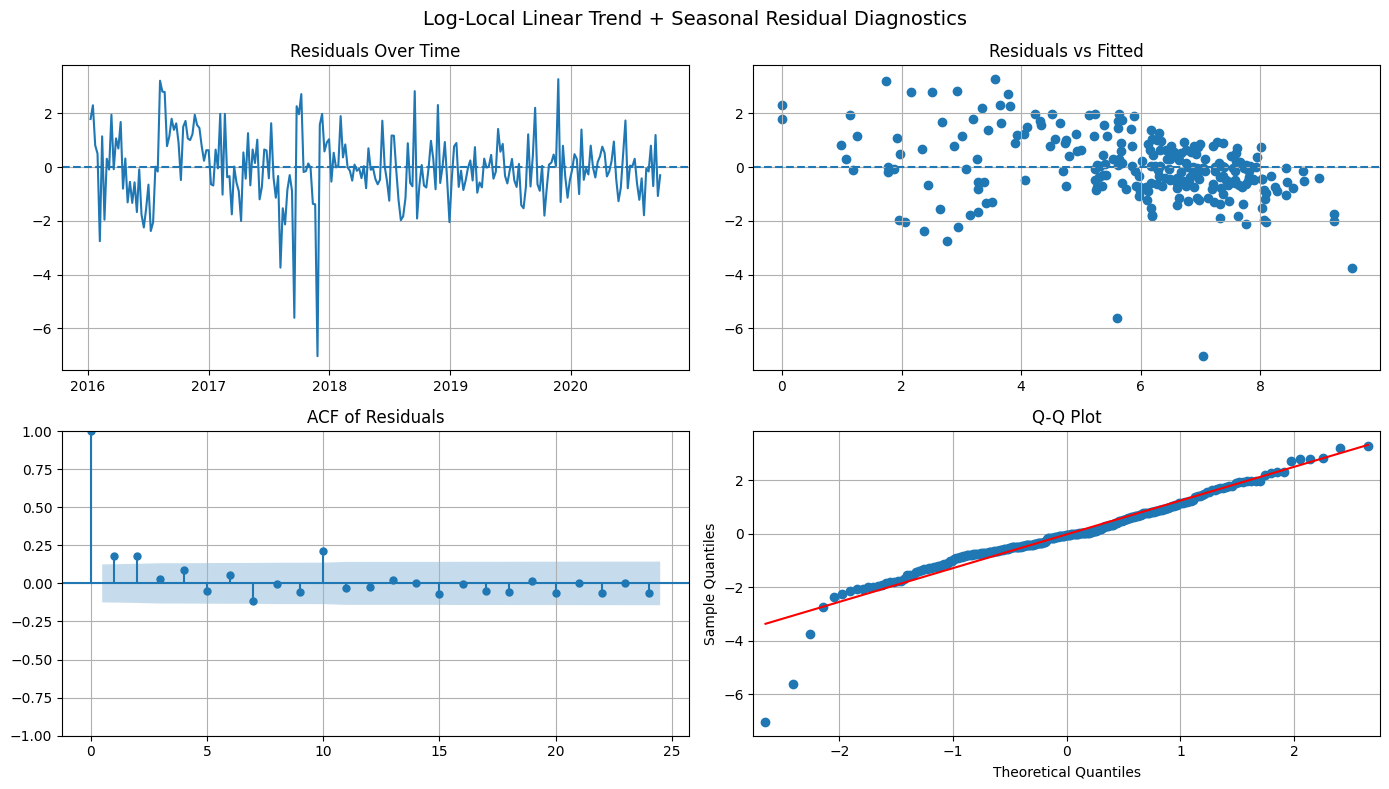

Ljung-Box Test:


,lb_stat,lb_pvalue
10,35.581254,0.000099
20,39.977611,0.005028


,lb_stat,lb_pvalue
10,35.581254,0.000099
20,39.977611,0.005028
30,49.587325,0.013684


In [85]:
residual_diagnostics(
    best_structural_model.resid,
    fitted_values=best_structural_model.fittedvalues,
    title=f"{best_structural_name} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(best_structural_model.resid).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [86]:
add_result(
    best_structural_name,
    test_series,
    best_structural_forecast
)

{'RMSE': 1365.2628283494141,
 'MAE': 916.746099424043,
 'R2': -0.004148942759054641,
 'nRMSE': 0.9825797225401195,
 'MAPE': 368.6708966716583,
 'SMAPE': 86.05295706896618}

#### Prophet

In [87]:
# ============================================================
# Prophet Models
# Research Question:
# Can Prophet's flexible additive decomposition capture mosquito
# trend and seasonal structure better than classical models?
# ============================================================

try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

In [88]:
def prepare_prophet_df(ts):
    df = ts.reset_index()
    df.columns = ["ds", "y"]
    return df

prophet_df = prepare_prophet_df(ts_series)

train_prophet = prophet_df.iloc[:train_size].copy()
test_prophet = prophet_df.iloc[train_size:].copy()

train_prophet.head()

,ds,y
0,2016-01-10,5
1,2016-01-17,9
2,2016-01-24,5
3,2016-01-31,11
4,2016-02-07,0


In [89]:
# ============================================================
# Prophet Hyperparameter Variations
# ============================================================

prophet_configs = [
    {
        "name": "Prophet Default",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Flexible Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.5,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Conservative Trend",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Multiplicative Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "name": "Prophet Strong Seasonality",
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 20.0
    },
]

In [90]:
prophet_results = []
prophet_models = {}
prophet_forecasts = {}

for config in prophet_configs:
    try:
        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast = np.maximum(test_forecast, 0)

        metrics = compute_metrics(test_series.values, test_forecast)

        prophet_results.append({
            "Model": config["name"],
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        prophet_models[config["name"]] = model
        prophet_forecasts[config["name"]] = forecast

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

prophet_results_df = pd.DataFrame(prophet_results).sort_values("RMSE").reset_index(drop=True)
prophet_results_df

16:38:39 - cmdstanpy - INFO - Chain [1] start processing
16:38:39 - cmdstanpy - INFO - Chain [1] done processing
16:38:39 - cmdstanpy - INFO - Chain [1] start processing


Prophet Default {'RMSE': 1081.3286703711212, 'MAE': 711.7275829239145, 'R2': 0.3700863209556181, 'nRMSE': 0.7782322955298445, 'MAPE': 277.4818618674923, 'SMAPE': 71.4465346212041}


16:38:40 - cmdstanpy - INFO - Chain [1] done processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing


Prophet Flexible Trend {'RMSE': 930.3157290202846, 'MAE': 698.1385578931066, 'R2': 0.5337419630829403, 'nRMSE': 0.6695482744524782, 'MAPE': 539.1769855177278, 'SMAPE': 62.36742894475328}


16:38:40 - cmdstanpy - INFO - Chain [1] done processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing


...

16:38:40 - cmdstanpy - INFO - Chain [1] done processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing


Prophet Multiplicative Seasonality {'RMSE': 826.8723080308089, 'MAE': 545.3415199999088, 'R2': 0.6316654153565644, 'nRMSE': 0.5951000394431628, 'MAPE': 418.78559594411075, 'SMAPE': 54.77485607517211}


16:38:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet Strong Seasonality {'RMSE': 1085.6537362565928, 'MAE': 715.5486001638112, 'R2': 0.36503722392946414, 'nRMSE': 0.7813450456534615, 'MAPE': 273.64513508248126, 'SMAPE': 72.78939444356325}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,826.872308,545.341520,0.631665,0.595100,418.785596,54.774856
1,Prophet Flexible Trend,additive,0.50,10.0,930.315729,698.138558,0.533742,0.669548,539.176986,62.367429
2,Prophet Conservative Trend,additive,0.01,10.0,991.874323,684.298528,0.469996,0.713852,440.802488,59.120426
3,Prophet Default,additive,0.05,10.0,1081.328670,711.727583,0.370086,0.778232,277.481862,71.446535
4,Prophet Strong Seasonality,additive,0.05,20.0,1085.653736,715.548600,0.365037,0.781345,273.645135,72.789394


Best Prophet model: Prophet Multiplicative Seasonality


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,826.872308,545.34152,0.631665,0.5951,418.785596,54.774856


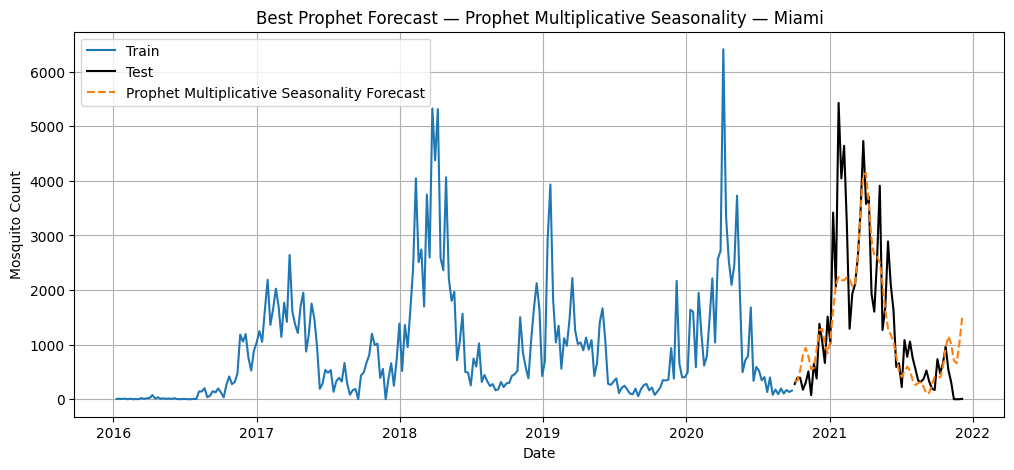

In [91]:
best_prophet_name = prophet_results_df.iloc[0]["Model"]
best_prophet_model = prophet_models[best_prophet_name]
best_prophet_forecast = prophet_forecasts[best_prophet_name]

print("Best Prophet model:", best_prophet_name)
display(prophet_results_df.iloc[[0]])

best_prophet_test_forecast = best_prophet_forecast.iloc[train_size:]["yhat"].values
best_prophet_test_forecast = np.maximum(best_prophet_test_forecast, 0)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_prophet_test_forecast,
    label=f"{best_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Prophet Forecast — {best_prophet_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

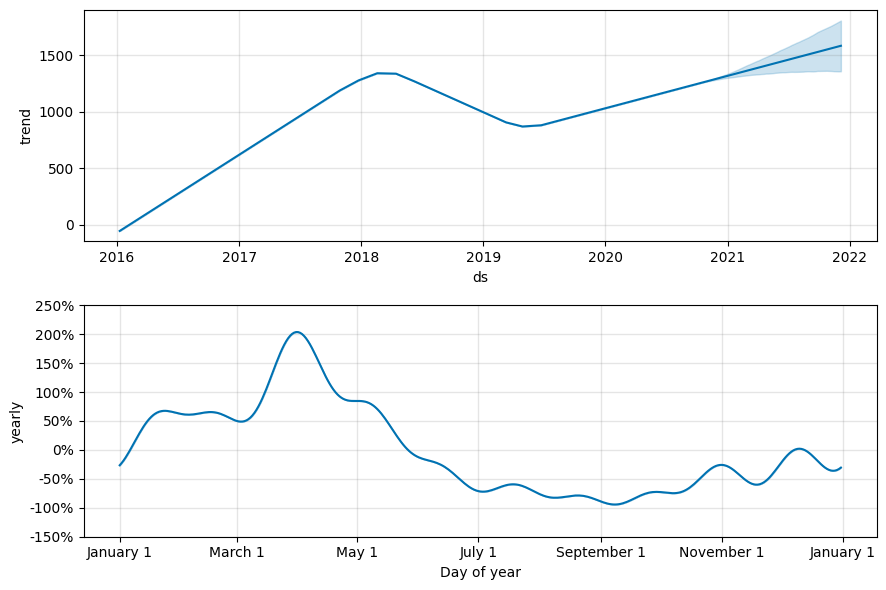

In [92]:
# ============================================================
# Prophet Component Decomposition
# ============================================================

best_prophet_model.plot_components(best_prophet_forecast)
plt.show()

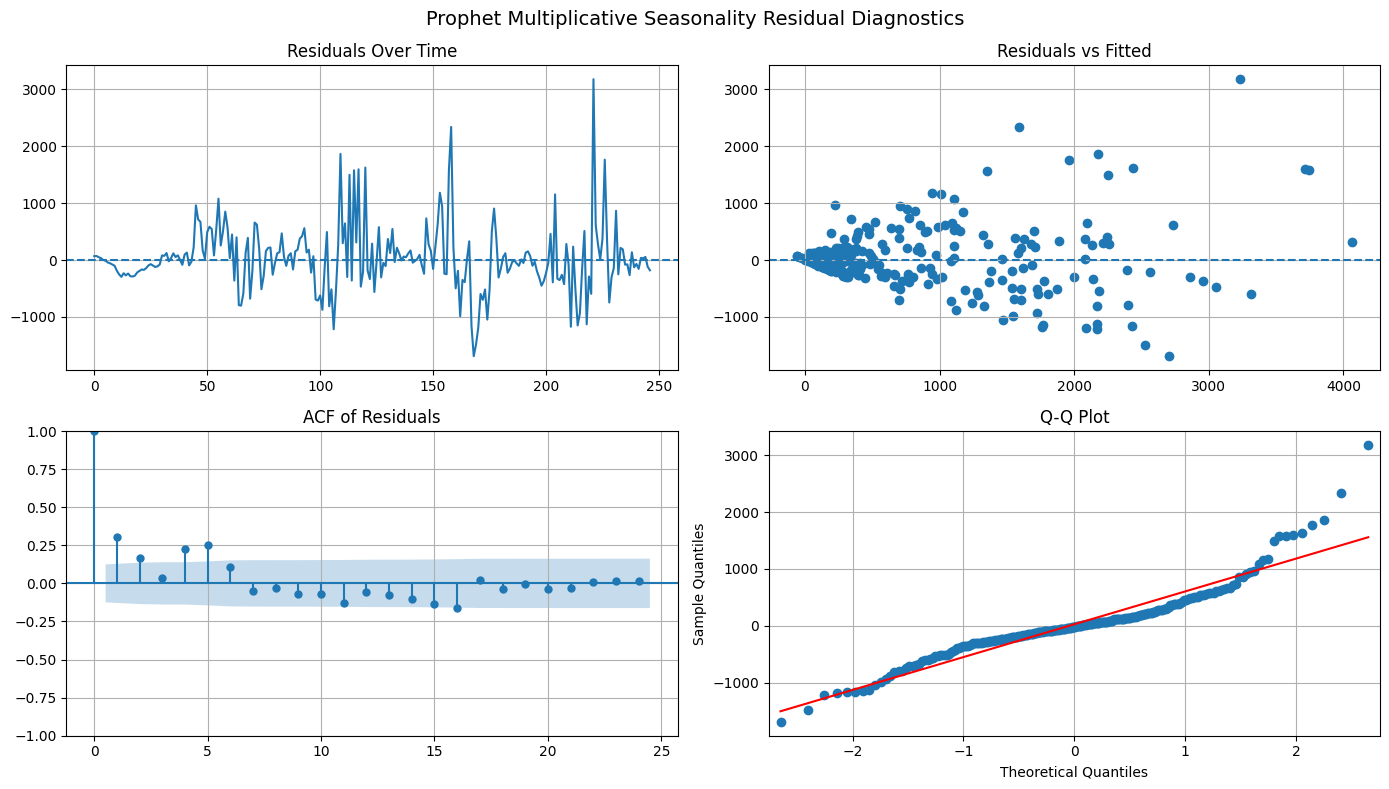

Ljung-Box Test:


,lb_stat,lb_pvalue
10,65.471503,3.292840e-10
20,87.754572,1.825716e-10


,lb_stat,lb_pvalue
10,65.471503,3.292840e-10
20,87.754572,1.825716e-10
30,89.354959,8.222930e-08


In [93]:
# ============================================================
# Prophet Residual Diagnostics
# ============================================================

prophet_train_forecast = best_prophet_forecast.iloc[:train_size]

prophet_train_residuals = (
    train_prophet["y"].values - prophet_train_forecast["yhat"].values
)

residual_diagnostics(
    prophet_train_residuals,
    fitted_values=prophet_train_forecast["yhat"].values,
    title=f"{best_prophet_name} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        pd.Series(prophet_train_residuals).dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

In [94]:
# ============================================================
# Log-Prophet Models
# Research Question:
# Does variance stabilization improve Prophet performance?
# ============================================================

log_prophet_df = prophet_df.copy()
log_prophet_df["y"] = np.log1p(log_prophet_df["y"])

log_train_prophet = log_prophet_df.iloc[:train_size].copy()
log_test_prophet = log_prophet_df.iloc[train_size:].copy()

log_prophet_results = []
log_prophet_models = {}
log_prophet_forecasts = {}

for config in prophet_configs:
    try:
        model_name = "Log-" + config["name"]

        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=False,
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )

        model.fit(log_train_prophet)

        future = model.make_future_dataframe(
            periods=len(test_prophet),
            freq="W"
        )

        forecast = model.predict(future)

        log_test_forecast = forecast.iloc[train_size:]["yhat"].values
        test_forecast_original = np.expm1(log_test_forecast)
        test_forecast_original = np.maximum(test_forecast_original, 0)

        metrics = compute_metrics(test_series.values, test_forecast_original)

        log_prophet_results.append({
            "Model": model_name,
            "Seasonality_Mode": config["seasonality_mode"],
            "Changepoint_Prior": config["changepoint_prior_scale"],
            "Seasonality_Prior": config["seasonality_prior_scale"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_prophet_models[model_name] = model
        log_prophet_forecasts[model_name] = forecast

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_prophet_results_df = pd.DataFrame(log_prophet_results).sort_values("RMSE").reset_index(drop=True)
log_prophet_results_df

16:41:20 - cmdstanpy - INFO - Chain [1] start processing
16:41:20 - cmdstanpy - INFO - Chain [1] done processing
16:41:20 - cmdstanpy - INFO - Chain [1] start processing


Log-Prophet Default {'RMSE': 1181.450950710683, 'MAE': 789.6134116621995, 'R2': 0.24803609310570085, 'nRMSE': 0.8502903054553536, 'MAPE': 234.30745643926386, 'SMAPE': 73.46021620740802}


16:41:20 - cmdstanpy - INFO - Chain [1] done processing
16:41:20 - cmdstanpy - INFO - Chain [1] start processing


Log-Prophet Flexible Trend {'RMSE': 897.2196559556007, 'MAE': 601.7406893530928, 'R2': 0.5663262232466875, 'nRMSE': 0.6457290290926816, 'MAPE': 288.9029850819393, 'SMAPE': 58.51712830447837}


16:41:20 - cmdstanpy - INFO - Chain [1] done processing
16:41:21 - cmdstanpy - INFO - Chain [1] start processing


...

16:41:21 - cmdstanpy - INFO - Chain [1] done processing
16:41:21 - cmdstanpy - INFO - Chain [1] start processing


Log-Prophet Multiplicative Seasonality {'RMSE': 1147.398201710203, 'MAE': 764.1965651486134, 'R2': 0.2907588371597316, 'nRMSE': 0.8257825403790333, 'MAPE': 196.41384861398822, 'SMAPE': 74.51101560670553}


16:41:21 - cmdstanpy - INFO - Chain [1] done processing


Log-Prophet Strong Seasonality {'RMSE': 1235.0478695456572, 'MAE': 828.652158439693, 'R2': 0.17826235116402533, 'nRMSE': 0.8888640104917264, 'MAPE': 212.56632352875263, 'SMAPE': 78.07789589024526}


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-Prophet Flexible Trend,additive,0.50,10.0,897.219656,601.740689,0.566326,0.645729,288.902985,58.517128
1,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,1147.398202,764.196565,0.290759,0.825783,196.413849,74.511016
2,Log-Prophet Default,additive,0.05,10.0,1181.450951,789.613412,0.248036,0.850290,234.307456,73.460216
3,Log-Prophet Strong Seasonality,additive,0.05,20.0,1235.047870,828.652158,0.178262,0.888864,212.566324,78.077896
4,Log-Prophet Conservative Trend,additive,0.01,10.0,2829.252641,2202.389548,-3.312301,2.036213,2067.555908,96.541919


In [95]:
all_prophet_results_df = pd.concat(
    [prophet_results_df, log_prophet_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_prophet_results_df

,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,826.872308,545.341520,0.631665,0.595100,418.785596,54.774856
1,Log-Prophet Flexible Trend,additive,0.50,10.0,897.219656,601.740689,0.566326,0.645729,288.902985,58.517128
2,Prophet Flexible Trend,additive,0.50,10.0,930.315729,698.138558,0.533742,0.669548,539.176986,62.367429
3,Prophet Conservative Trend,additive,0.01,10.0,991.874323,684.298528,0.469996,0.713852,440.802488,59.120426
4,Prophet Default,additive,0.05,10.0,1081.328670,711.727583,0.370086,0.778232,277.481862,71.446535
5,Prophet Strong Seasonality,additive,0.05,20.0,1085.653736,715.548600,0.365037,0.781345,273.645135,72.789394
6,Log-Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,1147.398202,764.196565,0.290759,0.825783,196.413849,74.511016
7,Log-Prophet Default,additive,0.05,10.0,1181.450951,789.613412,0.248036,0.850290,234.307456,73.460216
8,Log-Prophet Strong Seasonality,additive,0.05,20.0,1235.047870,828.652158,0.178262,0.888864,212.566324,78.077896
9,Log-Prophet Conservative Trend,additive,0.01,10.0,2829.252641,2202.389548,-3.312301,2.036213,2067.555908,96.541919


In [96]:
all_prophet_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}",
    "Changepoint_Prior": "{:.3f}",
    "Seasonality_Prior": "{:.2f}"
})

,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Multiplicative Seasonality,multiplicative,0.050,10.00,826.87,545.34,0.632,0.595,418.79,54.77
1,Log-Prophet Flexible Trend,additive,0.500,10.00,897.22,601.74,0.566,0.646,288.90,58.52
2,Prophet Flexible Trend,additive,0.500,10.00,930.32,698.14,0.534,0.670,539.18,62.37
3,Prophet Conservative Trend,additive,0.010,10.00,991.87,684.30,0.470,0.714,440.80,59.12
4,Prophet Default,additive,0.050,10.00,1081.33,711.73,0.370,0.778,277.48,71.45
5,Prophet Strong Seasonality,additive,0.050,20.00,1085.65,715.55,0.365,0.781,273.65,72.79
6,Log-Prophet Multiplicative Seasonality,multiplicative,0.050,10.00,1147.40,764.20,0.291,0.826,196.41,74.51
7,Log-Prophet Default,additive,0.050,10.00,1181.45,789.61,0.248,0.850,234.31,73.46
8,Log-Prophet Strong Seasonality,additive,0.050,20.00,1235.05,828.65,0.178,0.889,212.57,78.08
9,Log-Prophet Conservative Trend,additive,0.010,10.00,2829.25,2202.39,-3.312,2.036,2067.56,96.54


In [97]:
best_overall_prophet_name = all_prophet_results_df.iloc[0]["Model"]

if best_overall_prophet_name.startswith("Log-"):
    best_overall_prophet_model = log_prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = log_prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = True
else:
    best_overall_prophet_model = prophet_models[best_overall_prophet_name]
    best_overall_prophet_forecast = prophet_forecasts[best_overall_prophet_name]
    is_log_prophet = False

print("Best overall Prophet model:", best_overall_prophet_name)
display(all_prophet_results_df.iloc[[0]])

Best overall Prophet model: Prophet Multiplicative Seasonality


,Model,Seasonality_Mode,Changepoint_Prior,Seasonality_Prior,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Prophet Multiplicative Seasonality,multiplicative,0.05,10.0,826.872308,545.34152,0.631665,0.5951,418.785596,54.774856


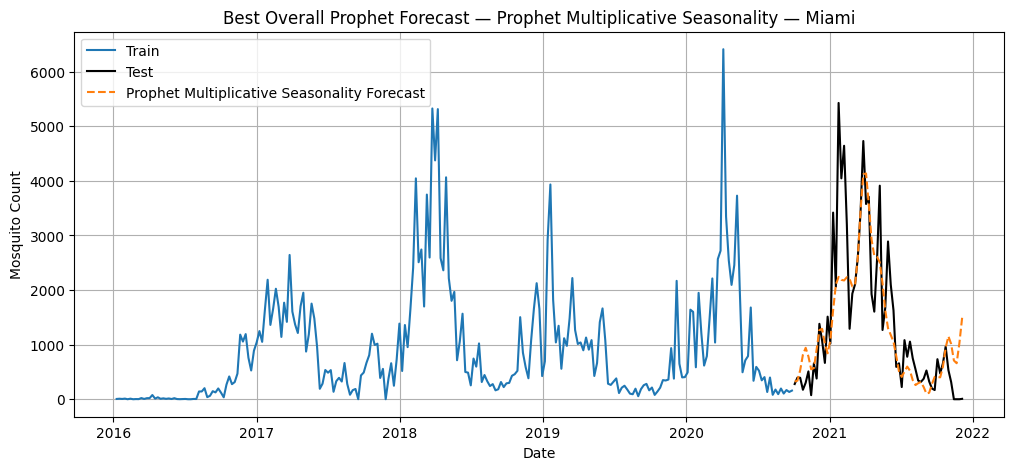

In [98]:
if is_log_prophet:
    best_overall_prophet_test_forecast = np.expm1(
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )
else:
    best_overall_prophet_test_forecast = (
        best_overall_prophet_forecast.iloc[train_size:]["yhat"].values
    )

best_overall_prophet_test_forecast = np.maximum(
    best_overall_prophet_test_forecast,
    0
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(test_series.index, test_series, label="Test", color="black")
plt.plot(
    test_series.index,
    best_overall_prophet_test_forecast,
    label=f"{best_overall_prophet_name} Forecast",
    linestyle="--"
)

plt.title(f"Best Overall Prophet Forecast — {best_overall_prophet_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

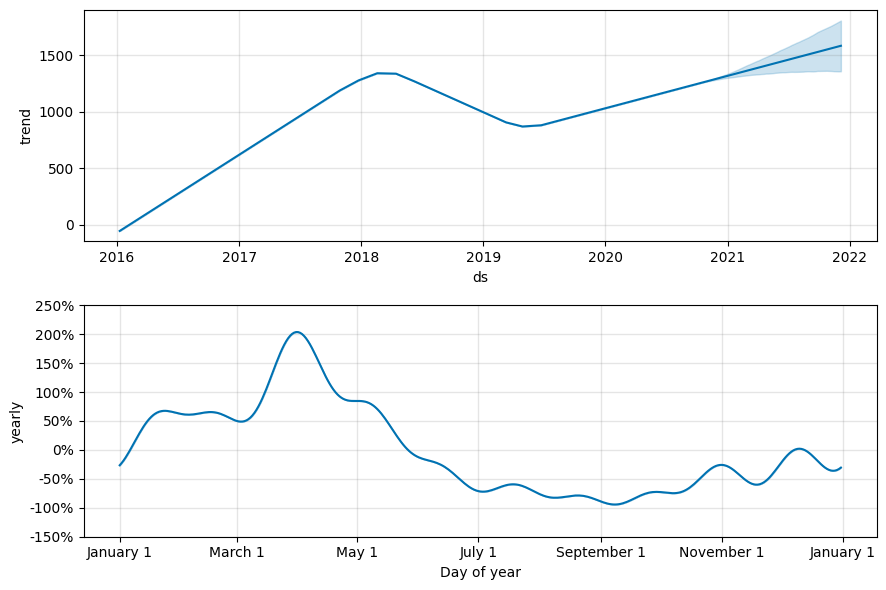

In [99]:
best_overall_prophet_model.plot_components(best_overall_prophet_forecast)
plt.show()

In [100]:
add_result(
    best_overall_prophet_name,
    test_series.values,
    best_overall_prophet_test_forecast
)

{'RMSE': 826.8723080308089,
 'MAE': 545.3415199999088,
 'R2': 0.6316654153565644,
 'nRMSE': 0.5951000394431628,
 'MAPE': 418.78559594411075,
 'SMAPE': 54.77485607517211}

#### LSTM

In [106]:
# ============================================================
# LSTM Model
# Research Question:
# Can a nonlinear sequence model learn temporal mosquito patterns
# that classical statistical models miss?
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

In [107]:
def create_lstm_sequences(data, lookback):
    """
    Converts a univariate time series into supervised learning sequences.

    X uses the previous `lookback` weeks.
    y is the next week's mosquito count.
    """
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [108]:
def fit_evaluate_lstm(train_series, test_series, lookback=12, units=64, dropout=0.2, epochs=150):
    """
    Fits and evaluates a univariate LSTM model.

    Scaling is fit only on the training data to avoid leakage.
    """
    
    scaler = MinMaxScaler()

    train_values = train_series.values.reshape(-1, 1)
    test_values = test_series.values.reshape(-1, 1)

    scaled_train = scaler.fit_transform(train_values)

    # Add final lookback observations from train before test
    combined_values = np.concatenate([train_values[-lookback:], test_values])
    scaled_combined = scaler.transform(combined_values)

    X_train, y_train = create_lstm_sequences(scaled_train, lookback)
    X_test, y_test = create_lstm_sequences(scaled_combined, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = Sequential([
        LSTM(units, activation="tanh", input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    y_pred = scaler.inverse_transform(pred_scaled).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    y_pred = np.maximum(y_pred, 0)

    metrics = compute_metrics(y_true, y_pred)

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "lookback": lookback,
        "units": units,
        "dropout": dropout,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": metrics
    }

In [109]:
# ============================================================
# LSTM Variations
# ============================================================

lstm_configs = [
    {"name": "LSTM Lookback 4", "lookback": 4, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 8", "lookback": 8, "units": 32, "dropout": 0.2},
    {"name": "LSTM Lookback 12", "lookback": 12, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 16", "lookback": 16, "units": 64, "dropout": 0.2},
    {"name": "LSTM Lookback 24", "lookback": 24, "units": 64, "dropout": 0.3},
]

lstm_results = []
lstm_outputs = {}

for config in lstm_configs:
    print("Fitting:", config["name"])

    try:
        output = fit_evaluate_lstm(
            train_series=train_series,
            test_series=test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        metrics = output["metrics"]

        lstm_results.append({
            "Model": config["name"],
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        lstm_outputs[config["name"]] = output

        print(config["name"], metrics)

    except Exception as e:
        print("Failed:", config["name"], "|", e)

lstm_results_df = pd.DataFrame(lstm_results).sort_values("RMSE").reset_index(drop=True)
lstm_results_df

Fitting: LSTM Lookback 4
LSTM Lookback 4 {'RMSE': 842.7832947101366, 'MAE': 560.1528821145334, 'R2': 0.6173537683903272, 'nRMSE': 0.6065511773135277, 'MAPE': 77.45817126602412, 'SMAPE': 54.996360055156}
Fitting: LSTM Lookback 8
LSTM Lookback 8 {'RMSE': 880.4728533426402, 'MAE': 588.6451496001213, 'R2': 0.5823643686809212, 'nRMSE': 0.6336763544551022, 'MAPE': 78.3560030070893, 'SMAPE': 56.0763733665099}
Fitting: LSTM Lookback 12
LSTM Lookback 12 {'RMSE': 966.2499311896055, 'MAE': 632.1466977519374, 'R2': 0.4970271354964796, 'nRMSE': 0.6954101214639574, 'MAPE': 107.38158948479865, 'SMAPE': 56.939131439361226}
Fitting: LSTM Lookback 16
LSTM Lookback 16 {'RMSE': 996.6635157508963, 'MAE': 637.9805814681515, 'R2': 0.4648657786411269, 'nRMSE': 0.7172987797201942, 'MAPE': 126.74505901744656, 'SMAPE': 56.48518991063074}
Fitting: LSTM Lookback 24
LSTM Lookback 24 {'RMSE': 992.6084336239129, 'MAE': 637.8079531269689, 'R2': 0.4692114753832356, 'nRMSE': 0.7143803369204105, 'MAPE': 113.69980886554, 

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,842.783295,560.152882,0.617354,0.606551,77.458171,54.996360
1,LSTM Lookback 8,8,32,0.2,880.472853,588.645150,0.582364,0.633676,78.356003,56.076373
2,LSTM Lookback 12,12,64,0.2,966.249931,632.146698,0.497027,0.695410,107.381589,56.939131
3,LSTM Lookback 24,24,64,0.3,992.608434,637.807953,0.469211,0.714380,113.699809,58.003255
4,LSTM Lookback 16,16,64,0.2,996.663516,637.980581,0.464866,0.717299,126.745059,56.485190


In [110]:
lstm_results_df.style.format({
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "R2": "{:.3f}",
    "nRMSE": "{:.3f}",
    "MAPE": "{:.2f}",
    "SMAPE": "{:.2f}"
})

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.200000,842.78,560.15,0.617,0.607,77.46,55.00
1,LSTM Lookback 8,8,32,0.200000,880.47,588.65,0.582,0.634,78.36,56.08
2,LSTM Lookback 12,12,64,0.200000,966.25,632.15,0.497,0.695,107.38,56.94
3,LSTM Lookback 24,24,64,0.300000,992.61,637.81,0.469,0.714,113.70,58.00
4,LSTM Lookback 16,16,64,0.200000,996.66,637.98,0.465,0.717,126.75,56.49


In [111]:
best_lstm_name = lstm_results_df.iloc[0]["Model"]
best_lstm_output = lstm_outputs[best_lstm_name]

print("Best LSTM model:", best_lstm_name)
display(lstm_results_df.iloc[[0]])

Best LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,842.783295,560.152882,0.617354,0.606551,77.458171,54.99636


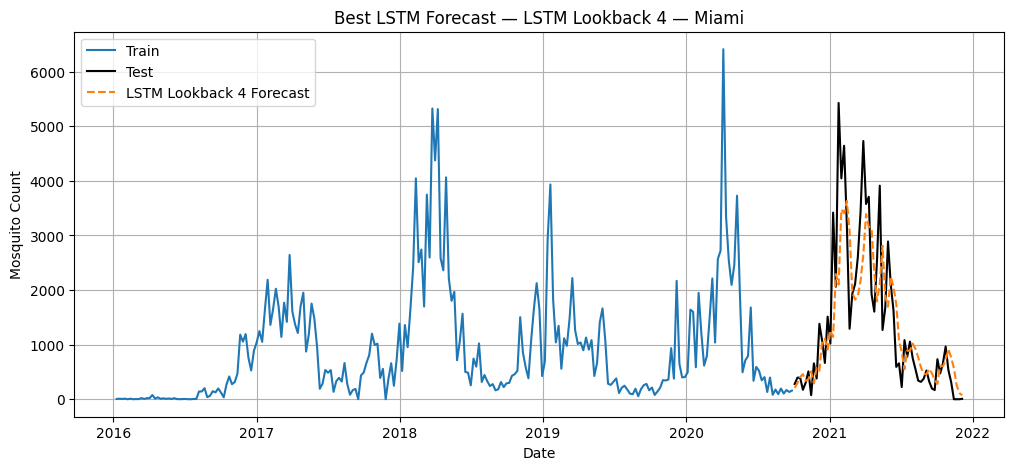

In [112]:
best_lookback = best_lstm_output["lookback"]

# LSTM forecasts align with the full test period because we used
# the final lookback weeks from training to predict the first test week.
lstm_test_index = test_series.index

best_lstm_true = pd.Series(
    best_lstm_output["y_true"],
    index=lstm_test_index,
    name="Observed"
)

best_lstm_pred = pd.Series(
    best_lstm_output["y_pred"],
    index=lstm_test_index,
    name="LSTM Forecast"
)

plt.figure(figsize=(12, 5))

plt.plot(train_series.index, train_series, label="Train")
plt.plot(best_lstm_true.index, best_lstm_true, label="Test", color="black")
plt.plot(
    best_lstm_pred.index,
    best_lstm_pred,
    label=f"{best_lstm_name} Forecast",
    linestyle="--"
)

plt.title(f"Best LSTM Forecast — {best_lstm_name} — Miami")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

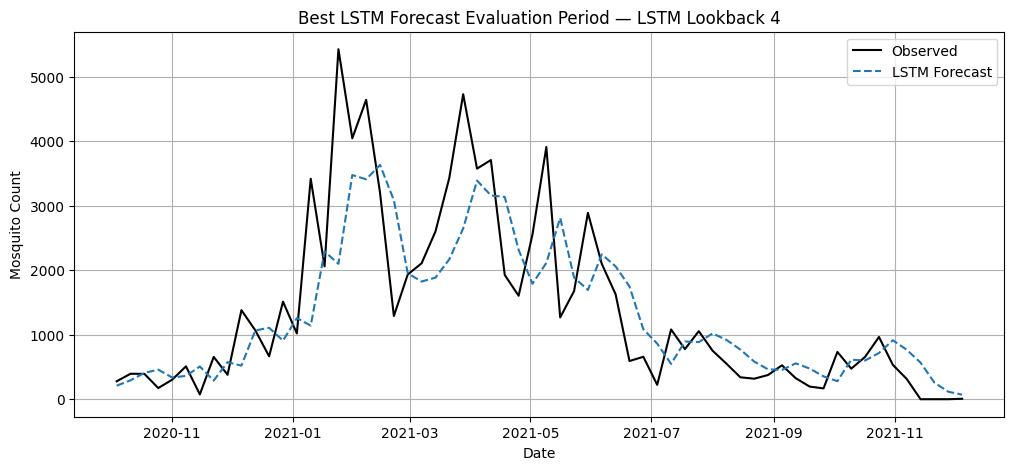

In [113]:
plt.figure(figsize=(12, 5))

plt.plot(best_lstm_true.index, best_lstm_true, label="Observed", color="black")
plt.plot(best_lstm_pred.index, best_lstm_pred, label="LSTM Forecast", linestyle="--")

plt.title(f"Best LSTM Forecast Evaluation Period — {best_lstm_name}")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.show()

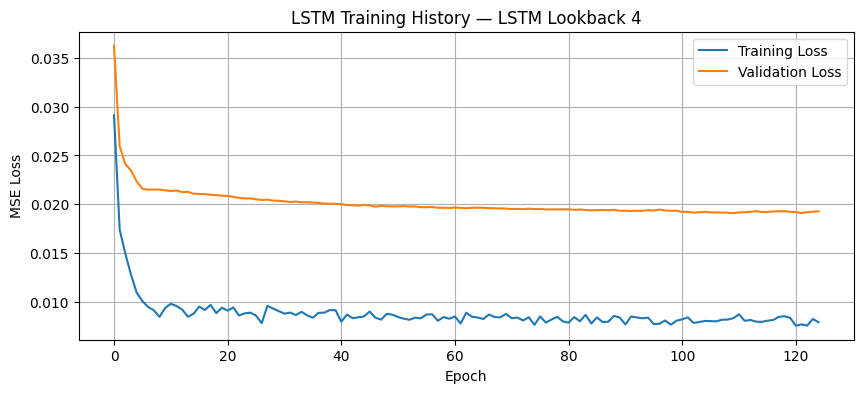

In [114]:
history = best_lstm_output["history"]

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title(f"LSTM Training History — {best_lstm_name}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

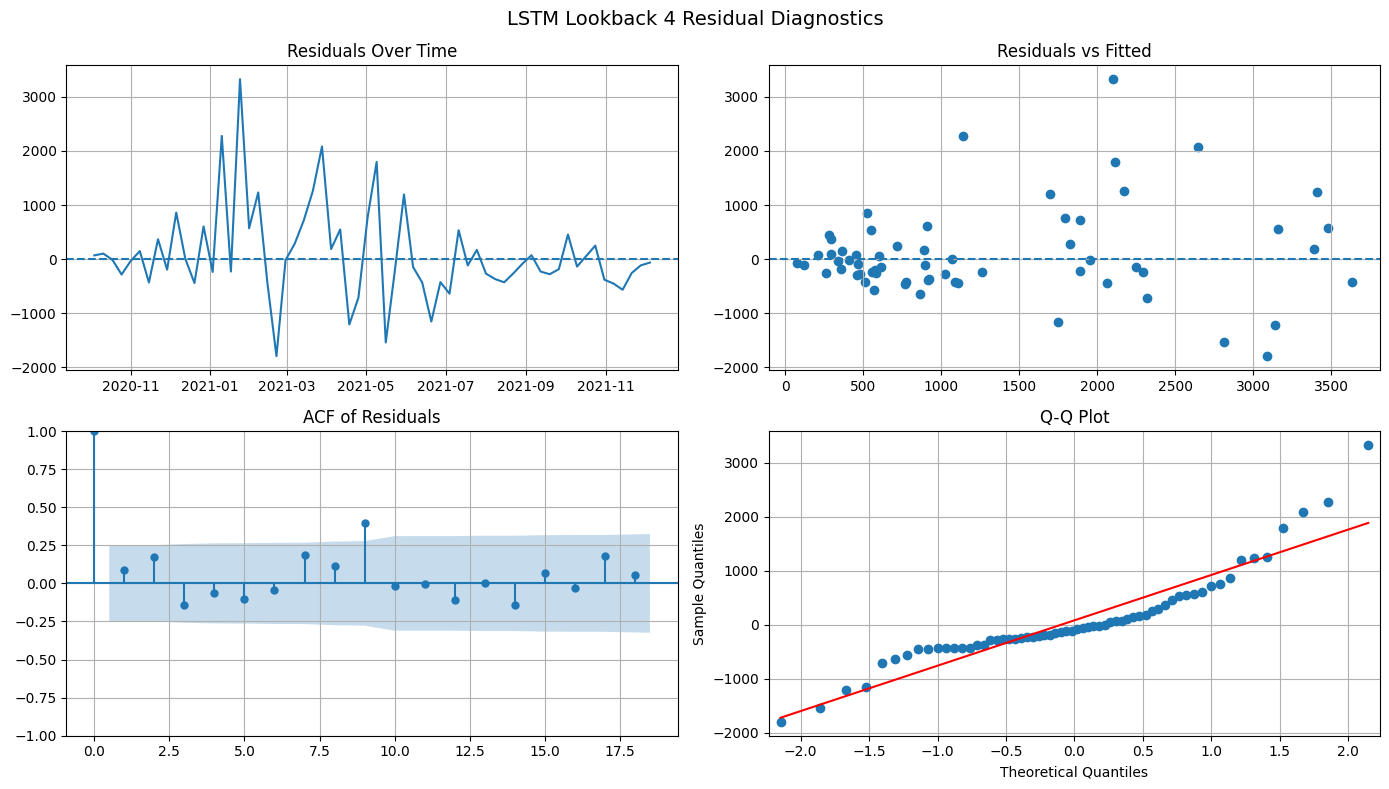

Ljung-Box Test:


,lb_stat,lb_pvalue
10,20.166138,0.027720
20,28.010907,0.109141


,lb_stat,lb_pvalue
10,20.166138,0.027720
20,28.010907,0.109141
30,33.473337,0.302373


In [115]:
lstm_residuals = best_lstm_true - best_lstm_pred

residual_diagnostics(
    lstm_residuals,
    fitted_values=best_lstm_pred,
    title=f"{best_lstm_name} Residual Diagnostics"
)

display(
    acorr_ljungbox(
        lstm_residuals.dropna(),
        lags=[10, 20, 30],
        return_df=True
    )
)

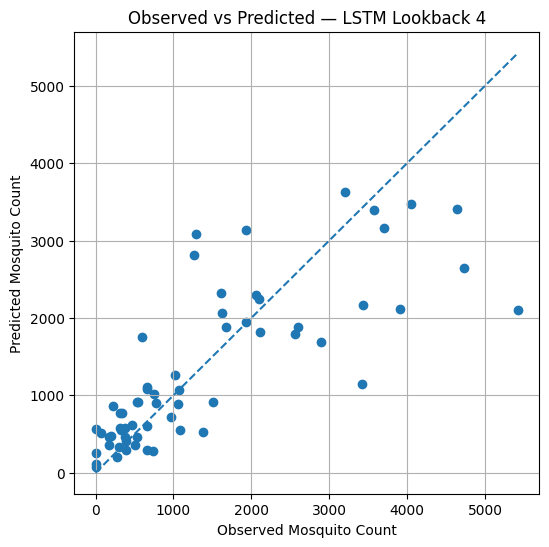

In [116]:
plt.figure(figsize=(6, 6))

plt.scatter(best_lstm_true, best_lstm_pred)

min_val = min(best_lstm_true.min(), best_lstm_pred.min())
max_val = max(best_lstm_true.max(), best_lstm_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title(f"Observed vs Predicted — {best_lstm_name}")
plt.xlabel("Observed Mosquito Count")
plt.ylabel("Predicted Mosquito Count")
plt.show()

In [117]:
add_result(
    best_lstm_name,
    best_lstm_true.values,
    best_lstm_pred.values
)

{'RMSE': 842.7832947101366,
 'MAE': 560.1528821145334,
 'R2': 0.6173537683903272,
 'nRMSE': 0.6065511773135277,
 'MAPE': 77.45817126602412,
 'SMAPE': 54.996360055156}

In [118]:
# ============================================================
# Optional Log-LSTM
# ============================================================

log_train_series = np.log1p(train_series)
log_test_series = np.log1p(test_series)

log_lstm_results = []
log_lstm_outputs = {}

for config in lstm_configs:
    model_name = "Log-" + config["name"]
    print("Fitting:", model_name)

    try:
        output = fit_evaluate_lstm(
            train_series=log_train_series,
            test_series=log_test_series,
            lookback=config["lookback"],
            units=config["units"],
            dropout=config["dropout"],
            epochs=150
        )

        # Back-transform true and predicted values
        y_true_original = np.expm1(output["y_true"])
        y_pred_original = np.expm1(output["y_pred"])
        y_pred_original = np.maximum(y_pred_original, 0)

        metrics = compute_metrics(y_true_original, y_pred_original)

        output["y_true_original"] = y_true_original
        output["y_pred_original"] = y_pred_original
        output["metrics_original"] = metrics

        log_lstm_results.append({
            "Model": model_name,
            "Lookback": config["lookback"],
            "Units": config["units"],
            "Dropout": config["dropout"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "nRMSE": metrics["nRMSE"],
            "MAPE": metrics["MAPE"],
            "SMAPE": metrics["SMAPE"]
        })

        log_lstm_outputs[model_name] = output

        print(model_name, metrics)

    except Exception as e:
        print("Failed:", model_name, "|", e)

log_lstm_results_df = pd.DataFrame(log_lstm_results).sort_values("RMSE").reset_index(drop=True)
log_lstm_results_df

Fitting: Log-LSTM Lookback 4
Log-LSTM Lookback 4 {'RMSE': 965.7191782681307, 'MAE': 620.5956117337752, 'R2': 0.4975795412266495, 'nRMSE': 0.6950281385611116, 'MAPE': 58.11563976448907, 'SMAPE': 57.65762475954256}
Fitting: Log-LSTM Lookback 8
Log-LSTM Lookback 8 {'RMSE': 1046.1770845323574, 'MAE': 658.4683630927918, 'R2': 0.4103748368512574, 'nRMSE': 0.7529336975287141, 'MAPE': 53.81128653577794, 'SMAPE': 58.4709392805101}
Fitting: Log-LSTM Lookback 12
Log-LSTM Lookback 12 {'RMSE': 920.9736079675171, 'MAE': 586.7179837688325, 'R2': 0.5430591625586002, 'nRMSE': 0.6628247494861811, 'MAPE': 54.424765066728476, 'SMAPE': 54.92634390196495}
Fitting: Log-LSTM Lookback 16
Log-LSTM Lookback 16 {'RMSE': 1006.6850817553925, 'MAE': 632.386020529655, 'R2': 0.4540500017275032, 'nRMSE': 0.7245113012505869, 'MAPE': 52.09187762460205, 'SMAPE': 57.10181515229974}
Fitting: Log-LSTM Lookback 24
Log-LSTM Lookback 24 {'RMSE': 1077.1402959367138, 'MAE': 660.3701507506835, 'R2': 0.37495663439808424, 'nRMSE': 0

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,Log-LSTM Lookback 12,12,64,0.2,920.973608,586.717984,0.543059,0.662825,54.424765,54.926344
1,Log-LSTM Lookback 4,4,32,0.2,965.719178,620.595612,0.497580,0.695028,58.115640,57.657625
2,Log-LSTM Lookback 16,16,64,0.2,1006.685082,632.386021,0.454050,0.724511,52.091878,57.101815
3,Log-LSTM Lookback 8,8,32,0.2,1046.177085,658.468363,0.410375,0.752934,53.811287,58.470939
4,Log-LSTM Lookback 24,24,64,0.3,1077.140296,660.370151,0.374957,0.775218,53.934635,57.985284


In [119]:
all_lstm_results_df = pd.concat(
    [lstm_results_df, log_lstm_results_df],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

all_lstm_results_df

,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,842.783295,560.152882,0.617354,0.606551,77.458171,54.996360
1,LSTM Lookback 8,8,32,0.2,880.472853,588.645150,0.582364,0.633676,78.356003,56.076373
2,Log-LSTM Lookback 12,12,64,0.2,920.973608,586.717984,0.543059,0.662825,54.424765,54.926344
3,Log-LSTM Lookback 4,4,32,0.2,965.719178,620.595612,0.497580,0.695028,58.115640,57.657625
4,LSTM Lookback 12,12,64,0.2,966.249931,632.146698,0.497027,0.695410,107.381589,56.939131
5,LSTM Lookback 24,24,64,0.3,992.608434,637.807953,0.469211,0.714380,113.699809,58.003255
6,LSTM Lookback 16,16,64,0.2,996.663516,637.980581,0.464866,0.717299,126.745059,56.485190
7,Log-LSTM Lookback 16,16,64,0.2,1006.685082,632.386021,0.454050,0.724511,52.091878,57.101815
8,Log-LSTM Lookback 8,8,32,0.2,1046.177085,658.468363,0.410375,0.752934,53.811287,58.470939
9,Log-LSTM Lookback 24,24,64,0.3,1077.140296,660.370151,0.374957,0.775218,53.934635,57.985284


In [120]:
best_overall_lstm_name = all_lstm_results_df.iloc[0]["Model"]

if best_overall_lstm_name.startswith("Log-"):
    best_overall_lstm_output = log_lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true_original"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred_original"],
        index=test_series.index
    )
else:
    best_overall_lstm_output = lstm_outputs[best_overall_lstm_name]
    best_overall_lstm_true = pd.Series(
        best_overall_lstm_output["y_true"],
        index=test_series.index
    )
    best_overall_lstm_pred = pd.Series(
        best_overall_lstm_output["y_pred"],
        index=test_series.index
    )

print("Best overall LSTM model:", best_overall_lstm_name)
display(all_lstm_results_df.iloc[[0]])

Best overall LSTM model: LSTM Lookback 4


,Model,Lookback,Units,Dropout,RMSE,MAE,R2,nRMSE,MAPE,SMAPE
0,LSTM Lookback 4,4,32,0.2,842.783295,560.152882,0.617354,0.606551,77.458171,54.99636


In [121]:
add_result(
    best_overall_lstm_name,
    best_overall_lstm_true.values,
    best_overall_lstm_pred.values
) 

{'RMSE': 842.7832947101366,
 'MAE': 560.1528821145334,
 'R2': 0.6173537683903272,
 'nRMSE': 0.6065511773135277,
 'MAPE': 77.45817126602412,
 'SMAPE': 54.996360055156}

#### Outbreak/Peak Analysis

In [123]:
# ============================================================
# Peak / Outbreak Performance Analysis
# ============================================================

def compute_peak_metrics(y_true, y_pred, percentile=90):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    threshold = np.percentile(y_true, percentile)
    peak_mask = y_true >= threshold

    if peak_mask.sum() == 0:
        return {
            "Peak_Threshold": threshold,
            "Peak_RMSE": np.nan,
            "Peak_MAE": np.nan,
            "Peak_Count": 0
        }

    return {
        "Peak_Threshold": threshold,
        "Peak_RMSE": np.sqrt(mean_squared_error(y_true[peak_mask], y_pred[peak_mask])),
        "Peak_MAE": mean_absolute_error(y_true[peak_mask], y_pred[peak_mask]),
        "Peak_Count": peak_mask.sum()
    }

In [124]:
peak_results = []

peak_results.append({
    "Model": f"Rolling ARIMA{best_arima_order}",
    **compute_peak_metrics(y_true_roll_arima, y_pred_roll_arima)
})

peak_results.append({
    "Model": best_overall_ets_name,
    **compute_peak_metrics(test_series.values, best_overall_ets_forecast.values)
})

peak_results.append({
    "Model": best_overall_prophet_name,
    **compute_peak_metrics(test_series.values, best_overall_prophet_test_forecast)
})

peak_results.append({
    "Model": best_overall_lstm_name,
    **compute_peak_metrics(best_overall_lstm_true.values, best_overall_lstm_pred.values)
})

peak_results_df = pd.DataFrame(peak_results).sort_values("Peak_RMSE").reset_index(drop=True)

display(peak_results_df)

,Model,Peak_Threshold,Peak_RMSE,Peak_MAE,Peak_Count
0,"Rolling ARIMA(3, 0, 4)",2597.0,1721.676961,1402.477997,26
1,LSTM Lookback 4,3560.7,1724.273636,1391.723947,7
2,Prophet Multiplicative Seasonality,3560.7,1787.578115,1461.022765,7
3,ETS Add Trend + Add Season,3560.7,2506.127246,2338.727803,7
